In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import requests
from torchsummary import summary
import math

In [ ]:
file_location='./input.txt'

with open(file_location) as f:
    text=f.read().strip()
chars= sorted(list(set(text)))
char_to_idx= dict()
idx_to_char = dict()
for index,val in enumerate(chars):
    char_to_idx[val]=index
    idx_to_char[index]=val

#encode text
vocab_size=len(char_to_idx)
encoded_text= [char_to_idx[ch]for ch in text]
print(f" text length: {len(text)} characters")
print(f"vocab_size: {vocab_size}")
print(f"First 20 encoded: {encoded_text[:20]}")
print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")

 text length: 2386 characters
vocab_size: 45
First 20 encoded: [13, 23, 42, 38, 1, 21, 26, 19, 36, 19, 21, 38, 23, 36, 1, 34, 36, 23, 22, 27]
Which decodes to: Next character predi


In [2]:
def create_input_output_seq(encoded_text,seq_len):
    inputs=[]
    targets=[]
    for i in range(len(encoded_text)-seq_len):
        input_seq=encoded_text[i:i+seq_len]
        target_seq=encoded_text[i+1:i+seq_len+1]
        inputs.append(input_seq)
        targets.append(target_seq)
    X=np.array(inputs)
    y=np.array(targets)

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    X_train=torch.tensor(X_train,dtype=torch.long)
    X_test=torch.tensor(X_test,dtype=torch.long)
    y_train=torch.tensor(y_train,dtype=torch.long)
    y_test=torch.tensor(y_test,dtype=torch.long)

    print(f"\nseq_len = {seq_len}")
    print(f"  Total samples : {len(X)}")
    print(f"  X_train shape : {X_train.shape}")   # (N_train, seq_len)
    print(f"  y_train shape : {y_train.shape}")   # (N_train, seq_len)
    print(f"  X_test shape   : {X_test.shape}")
    print(f"  y_test shape   : {y_test.shape}")

    return X_train, X_test, y_train, y_test

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model,dropout,max_length=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        encoding = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length, dtype=torch.float).reshape(-1,1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        encoding = encoding.unsqueeze(0)
        self.register_buffer('encoding', encoding)
    def forward(self, x):
        return self.dropout(x + self.encoding[:, :x.size(1)].detach())




In [8]:
class CharTransformer(nn.Module):
    def __init__(self, eta, n_iter,batch_size, random_state, vocab_size, hidden_size,num_layers,nhead, dropout=0.2):
        super().__init__()
        self.eta=eta
        self.n_iter = n_iter
        self.batch_size=batch_size
        self.random_state= random_state
        self.hidden_size = hidden_size
        self.vocab_size= vocab_size

        torch.manual_seed(self.random_state)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
        print(f'Using {self.device}')

        self.embedding=nn.Embedding(vocab_size,hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size,dropout)
        encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.softmax = nn.Softmax(dim=2)

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []
        self.to(self.device)

    def forward(self,x):
        seq_len = x.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(x.device)
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded, mask= causal_mask)
        output = self.fc(transformer_output)
        return output

    def iter_mini_batch(self,X,y):
        dataSet=TensorDataset(X,y)
        dataLoader=DataLoader(dataSet, batch_size=self.batch_size,shuffle=True)
        return dataLoader

    def fit(self,X_train,y_train,X_test,y_test):
        start_time=time.time()
        optimizer = optim.Adam(self.parameters(),lr=self.eta, weight_decay=0.001)
        criterion= nn.CrossEntropyLoss()

        for epoch in range(self.n_iter):
            epoch_start=time.time()
            self.train()
            train_loader=self.iter_mini_batch(X_train,y_train)
            running_loss=0.0
            correct=0
            total =0

            for xin,target in train_loader:
                xin=xin.to(self.device)
                target=target.to(self.device)
                optimizer.zero_grad()
                y_hat=self(xin)
                loss = criterion(y_hat.view(-1, y_hat.size(-1)), target.view(-1))
                loss.backward()
                optimizer.step()

                running_loss+=loss.item()
                preds = y_hat.argmax(dim=-1)
                correct += (preds == target).sum().item()
                total += target.numel()
            epoch_time =time.time()-epoch_start
            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total

            self.train_losses_.append(epoch_loss)
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_test, y_test, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)
            current_lr = optimizer.param_groups[0]['lr']

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% |'
                  f'lr: {current_lr:.6f} |'
                  f'Time: {epoch_time:.1f}s')

        self.training_time_ = time.time() - start_time    #stop the clock
        mins = self.training_time_ // 60
        secs = self.training_time_ % 60
        print(f"\nTraining complete: {int(mins)}m {secs:.1f}s")
        return self

    def _evaluate(self, X_test, y_test, criterion):
        test_loader=self.iter_mini_batch(X_test,y_test)
        self.eval()
        running_loss = 0.0
        correct      = 0
        total        = 0
        with torch.no_grad():
            for xin, target in test_loader:
                xin = xin.to(self.device)
                target = target.to(self.device)

                outputs = self(xin)
                loss=criterion(outputs.view(-1, outputs.size(-1)), target.view(-1))

                running_loss+= loss.item()
                predicted = outputs.argmax(dim=-1)
                total += target.numel()
                correct += (predicted == target).sum().item()
        val_loss = running_loss / len(test_loader)
        val_acc  = 100.0 * correct / total
        return val_loss, val_acc
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    def generate(self, seed_text, char_to_idx, idx_to_char, length=200,
             temperature=1.0, max_context=30, greedy=False):
      self.eval()
      generated = [char_to_idx[ch] for ch in seed_text]

      with torch.no_grad():
          for _ in range(length):
              context = generated[-max_context:]
              x = torch.tensor([context], dtype=torch.long, device=self.device)
              logits = self(x)
              last_logits = logits[0, -1, :]
              if greedy:
                  next_idx = last_logits.argmax(dim=-1).item()
              else:
                  probs = torch.softmax(last_logits / temperature, dim=-1)
                  next_idx = torch.multinomial(probs, num_samples=1).item()
              generated.append(next_idx)

      return ''.join(idx_to_char[i] for i in generated)

In [ ]:
seq_lengths = [10, 20, 30]
datasets = {}
models = {}


hp = dict(eta=1e-3, n_iter=50, batch_size=32, random_state=42,
          vocab_size=vocab_size, hidden_size=64, num_layers=2, nhead=4, dropout=0.1)

for sl in seq_lengths:
    X_train, X_test, y_train, y_test = create_input_output_seq(encoded_text, sl)
    datasets[sl] = (X_train, X_test, y_train, y_test)

    model = CharTransformer(**hp)
    model.fit(X_train, y_train, X_test, y_test)
    models[sl] = model


seq_len = 10
  Total samples : 2376
  X_train shape : torch.Size([1900, 10])
  y_train shape : torch.Size([1900, 10])
  X_test shape   : torch.Size([476, 10])
  y_test shape   : torch.Size([476, 10])
Using mps
Epoch   1/50 | Loss: 2.7169 | Acc: 24.23% | Val Loss: 2.3491 | Val Acc: 31.66% |lr: 0.001000 |Time: 0.7s
Epoch   2/50 | Loss: 2.2754 | Acc: 33.01% | Val Loss: 2.1271 | Val Acc: 38.00% |lr: 0.001000 |Time: 0.7s
Epoch   3/50 | Loss: 2.0721 | Acc: 39.68% | Val Loss: 1.9569 | Val Acc: 44.29% |lr: 0.001000 |Time: 0.7s
Epoch   4/50 | Loss: 1.9236 | Acc: 43.28% | Val Loss: 1.8061 | Val Acc: 46.20% |lr: 0.001000 |Time: 0.7s
Epoch   5/50 | Loss: 1.8060 | Acc: 45.79% | Val Loss: 1.6931 | Val Acc: 49.43% |lr: 0.001000 |Time: 0.7s
Epoch   6/50 | Loss: 1.7082 | Acc: 48.75% | Val Loss: 1.5952 | Val Acc: 51.22% |lr: 0.001000 |Time: 0.7s
Epoch   7/50 | Loss: 1.6256 | Acc: 50.14% | Val Loss: 1.5348 | Val Acc: 52.86% |lr: 0.001000 |Time: 0.8s
Epoch   8/50 | Loss: 1.5540 | Acc: 51.66% | Val Loss: 

In [ ]:

for sl, model in models.items():
    print(f"seq_len={sl}: {model.count_parameters():,} trainable parameters")



seq_len=10: 568,109 trainable parameters
seq_len=20: 568,109 trainable parameters
seq_len=30: 568,109 trainable parameters


In [ ]:

rows = []
for sl in seq_lengths:
    model = models[sl]
    n_params = model.count_parameters()
    theoretical_attn_flops = sl**2 * hp['hidden_size'] * hp['num_layers']
    rows.append({
        'seq_len': sl,
        'params': n_params,
        'final_train_loss': model.train_losses_[-1],
        'final_val_acc': model.val_accuracies_[-1],
        'training_time_s': model.training_time_,
        'theoretical_attn_compute (n^2 * d * layers)': theoretical_attn_flops,
    })

pd.DataFrame(rows)

,seq_len,params,final_train_loss,final_val_acc,training_time_s,theoretical_attn_compute (n^2 * d * layers)
0,10,568109,0.904894,73.634454,34.626972,12800
1,20,568109,0.584902,86.540084,34.240312,51200
2,30,568109,0.447810,90.670904,34.025669,115200


In [5]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()

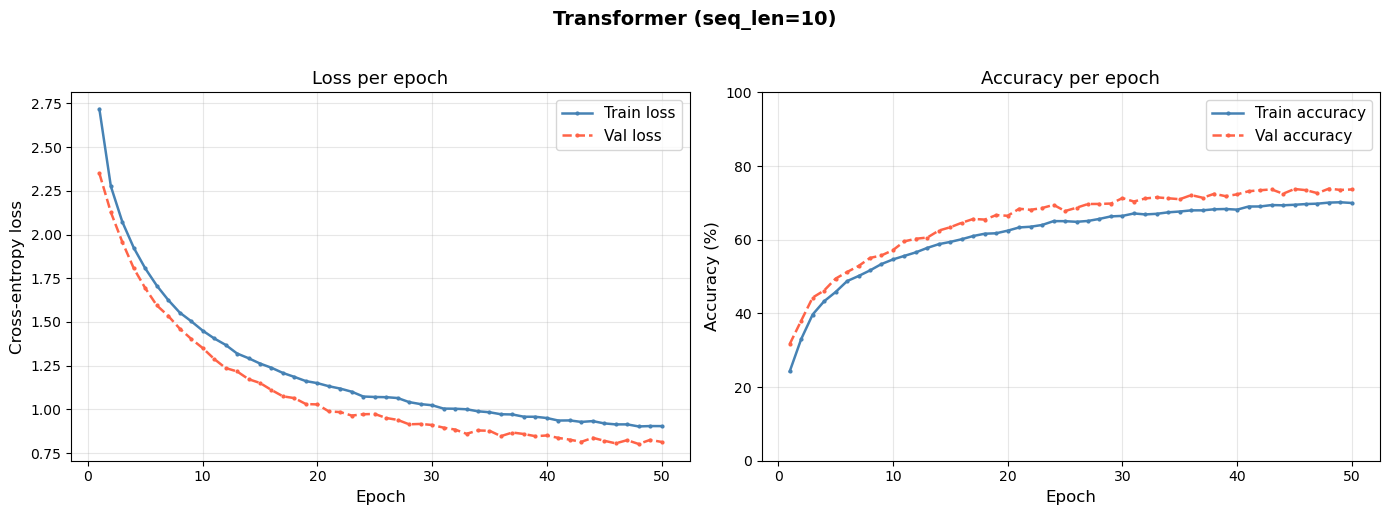

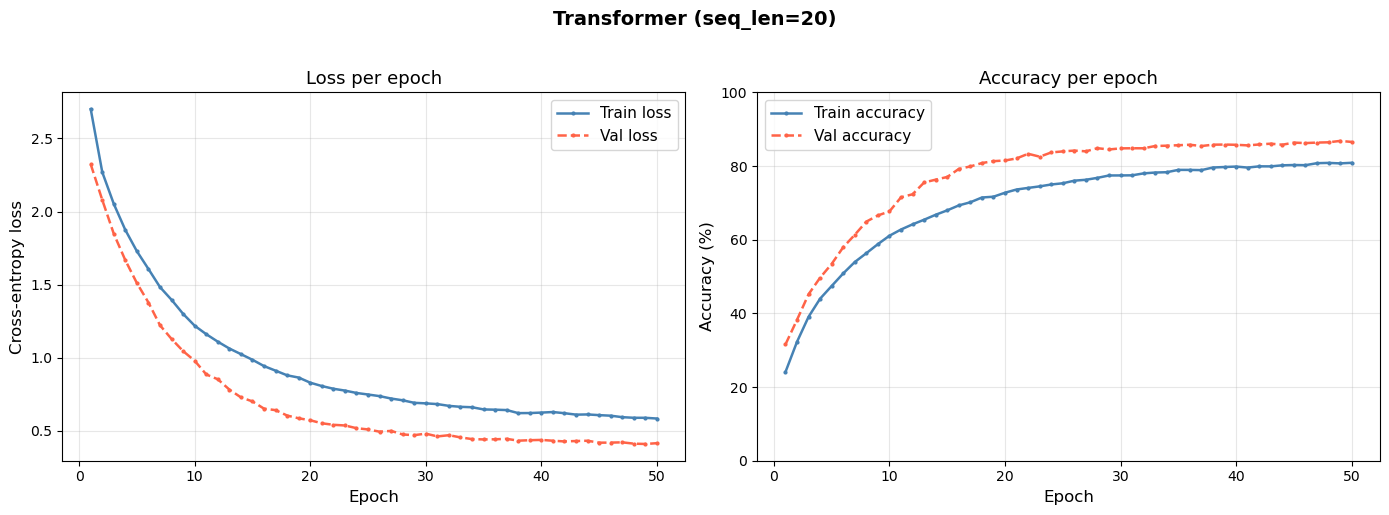

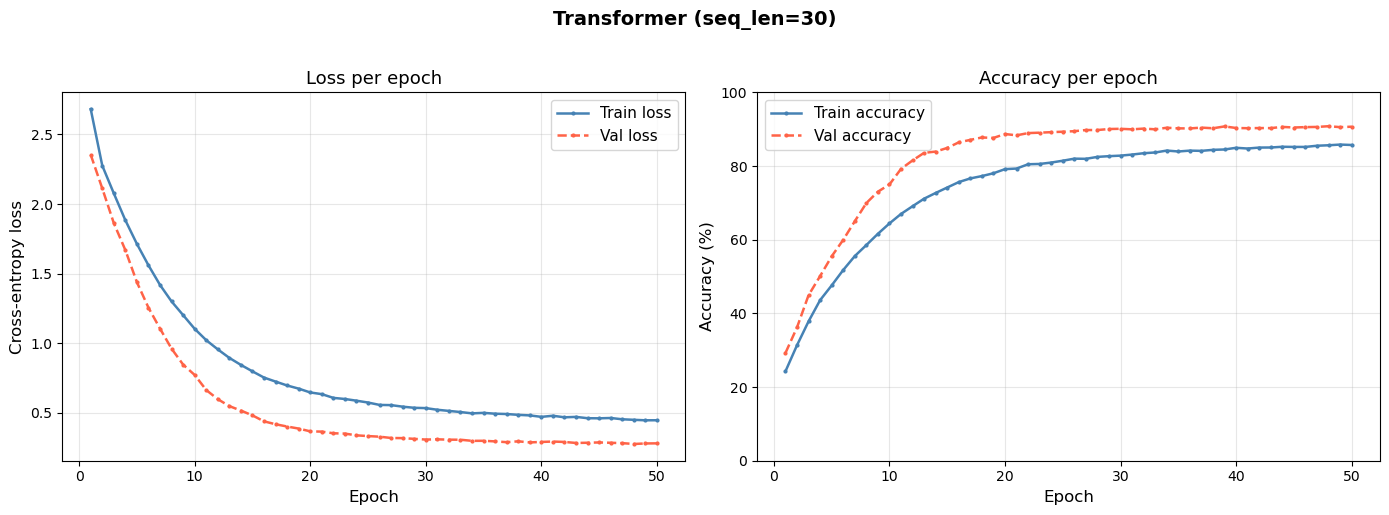

In [ ]:
for seq_len, model in models.items():
    plot_curves(model, title=f"Transformer (seq_len={seq_len})")

In [10]:
def load_shakespeare():
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    response = requests.get(url)
    text = response.text
    chars = sorted(list(set(text)))
    char_to_idx = dict()
    idx_to_char = dict()
    for index, val in enumerate(chars):
        char_to_idx[val] = index
        idx_to_char[index] = val

    vocab_size = len(char_to_idx)
    encoded_text = [char_to_idx[ch] for ch in text]
    print(f" text length: {len(text)} characters")
    print(f"vocab_size: {vocab_size}")
    print(f"First 20 encoded: {encoded_text[:20]}")
    print(f"Which decodes to: {''.join([idx_to_char[i] for i in encoded_text[:20]])}")
    return encoded_text, char_to_idx, idx_to_char

shakespeare_encoded_text, char_to_idx, idx_to_char = load_shakespeare()

 text length: 1115394 characters
vocab_size: 65
First 20 encoded: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]
Which decodes to: First Citizen:
Befor


In [ ]:
BATCH_SIZE = 128
N_ITER = 25
baseline_results = {}
for sl in [20, 30]:
    X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, sl)
    model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                             vocab_size=65, hidden_size=64, num_layers=2, nhead=2, dropout=0.1)
    model.fit(X_train, y_train, X_test, y_test)
    baseline_results[sl] = model

sweep_results = []
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, seq_len=20)

for num_layers in [1, 2, 4]:
    for nhead in [2, 4]:
        model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                                 vocab_size=65, hidden_size=64, num_layers=num_layers,
                                 nhead=nhead, dropout=0.1)
        model.fit(X_train, y_train, X_test, y_test)

        final_val_loss = model.val_losses_[-1]
        perplexity = math.exp(final_val_loss)

        sweep_results.append({
            'num_layers': num_layers,
            'nhead': nhead,
            'params': model.count_parameters(),
            'final_train_loss': model.train_losses_[-1],
            'final_val_loss': final_val_loss,
            'val_perplexity': perplexity,
            'final_val_acc': model.val_accuracies_[-1],
            'training_time_s': model.training_time_,
        })

sweep_df = pd.DataFrame(sweep_results)


seq_len = 20
  Total samples : 1115374
  X_train shape : torch.Size([892299, 20])
  y_train shape : torch.Size([892299, 20])
  X_test shape   : torch.Size([223075, 20])
  y_test shape   : torch.Size([223075, 20])
Using cuda
Epoch   1/25 | Loss: 2.1210 | Acc: 37.85% | Val Loss: 1.8989 | Val Acc: 43.81% |lr: 0.001000 |Time: 58.3s
Epoch   2/25 | Loss: 1.9901 | Acc: 41.24% | Val Loss: 1.8451 | Val Acc: 45.02% |lr: 0.001000 |Time: 57.9s
Epoch   3/25 | Loss: 1.9623 | Acc: 42.01% | Val Loss: 1.8322 | Val Acc: 45.72% |lr: 0.001000 |Time: 56.6s
Epoch   4/25 | Loss: 1.9493 | Acc: 42.38% | Val Loss: 1.8096 | Val Acc: 46.14% |lr: 0.001000 |Time: 56.2s
Epoch   5/25 | Loss: 1.9421 | Acc: 42.58% | Val Loss: 1.8024 | Val Acc: 46.19% |lr: 0.001000 |Time: 56.4s
Epoch   6/25 | Loss: 1.9375 | Acc: 42.71% | Val Loss: 1.7935 | Val Acc: 46.57% |lr: 0.001000 |Time: 56.3s
Epoch   7/25 | Loss: 1.9334 | Acc: 42.82% | Val Loss: 1.7846 | Val Acc: 46.69% |lr: 0.001000 |Time: 55.9s
Epoch   8/25 | Loss: 1.9307 | Acc

In [ ]:
sweep_df

,num_layers,nhead,params,final_train_loss,final_val_loss,val_perplexity,final_val_acc,training_time_s
0,1,2,289537,2.078010,1.918430,6.810261,42.917046,979.162806
1,1,4,289537,2.049380,1.894953,6.652236,43.638933,999.106729
2,2,2,570689,1.919467,1.774300,5.896150,47.123165,1542.240521
3,2,4,570689,1.877985,1.740931,5.702648,47.955239,1598.471166
4,4,2,1132993,1.816202,1.678000,5.354835,49.267870,2694.759096
5,4,4,1132993,1.797361,1.670814,5.316494,49.532108,2811.810910


In [ ]:
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, seq_len=50)
model_50 = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                            vocab_size=65, hidden_size=64, num_layers=2, nhead=2, dropout=0.1)
model_50.fit(X_train, y_train, X_test, y_test)

print(f"params: {model_50.count_parameters()}")
print(f"final val loss: {model_50.val_losses_[-1]:.4f}, "
      f"val acc: {model_50.val_accuracies_[-1]:.2f}%, "
      f"perplexity: {math.exp(model_50.val_losses_[-1]):.2f}")


seq_len = 50
  Total samples : 1115344
  X_train shape : torch.Size([892275, 50])
  y_train shape : torch.Size([892275, 50])
  X_test shape   : torch.Size([223069, 50])
  y_test shape   : torch.Size([223069, 50])
Using cuda
Epoch   1/25 | Loss: 2.1022 | Acc: 38.24% | Val Loss: 1.8268 | Val Acc: 45.77% |lr: 0.001000 |Time: 113.8s
Epoch   2/25 | Loss: 1.9499 | Acc: 42.27% | Val Loss: 1.7672 | Val Acc: 47.26% |lr: 0.001000 |Time: 115.2s
Epoch   3/25 | Loss: 1.9203 | Acc: 43.16% | Val Loss: 1.7427 | Val Acc: 48.12% |lr: 0.001000 |Time: 115.1s
Epoch   4/25 | Loss: 1.9069 | Acc: 43.55% | Val Loss: 1.7285 | Val Acc: 48.27% |lr: 0.001000 |Time: 114.9s
Epoch   5/25 | Loss: 1.8988 | Acc: 43.78% | Val Loss: 1.7245 | Val Acc: 48.49% |lr: 0.001000 |Time: 114.8s
Epoch   6/25 | Loss: 1.8934 | Acc: 43.93% | Val Loss: 1.7142 | Val Acc: 48.77% |lr: 0.001000 |Time: 114.9s
Epoch   7/25 | Loss: 1.8895 | Acc: 44.03% | Val Loss: 1.7085 | Val Acc: 48.87% |lr: 0.001000 |Time: 114.9s
Epoch   8/25 | Loss: 1.886

In [7]:
BATCH_SIZE = 128
N_ITER = 5
baseline_results = {}
for sl in [20, 30]:
    X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, sl)
    model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                             vocab_size=65, hidden_size=64, num_layers=2, nhead=2, dropout=0.1)
    model.fit(X_train, y_train, X_test, y_test)
    baseline_results[sl] = model

sweep_results = []
X_train, X_test, y_train, y_test = create_input_output_seq(shakespeare_encoded_text, seq_len=20)

for num_layers in [1, 2, 4]:
    for nhead in [2, 4]:
        model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                                 vocab_size=65, hidden_size=64, num_layers=num_layers,
                                 nhead=nhead, dropout=0.1)
        model.fit(X_train, y_train, X_test, y_test)

        final_val_loss = model.val_losses_[-1]
        perplexity = math.exp(final_val_loss)

        sweep_results.append({
            'num_layers': num_layers,
            'nhead': nhead,
            'params': model.count_parameters(),
            'final_train_loss': model.train_losses_[-1],
            'final_val_loss': final_val_loss,
            'val_perplexity': perplexity,
            'final_val_acc': model.val_accuracies_[-1],
            'training_time_s': model.training_time_,
        })

sweep_df = pd.DataFrame(sweep_results)


seq_len = 20
  Total samples : 1115374
  X_train shape : torch.Size([892299, 20])
  y_train shape : torch.Size([892299, 20])
  X_test shape   : torch.Size([223075, 20])
  y_test shape   : torch.Size([223075, 20])
Using cuda
Epoch   1/5 | Loss: 2.1210 | Acc: 37.85% | Val Loss: 1.8989 | Val Acc: 43.81% |lr: 0.001000 |Time: 56.0s
Epoch   2/5 | Loss: 1.9901 | Acc: 41.24% | Val Loss: 1.8451 | Val Acc: 45.02% |lr: 0.001000 |Time: 56.7s
Epoch   3/5 | Loss: 1.9623 | Acc: 42.01% | Val Loss: 1.8322 | Val Acc: 45.72% |lr: 0.001000 |Time: 55.5s
Epoch   4/5 | Loss: 1.9493 | Acc: 42.38% | Val Loss: 1.8096 | Val Acc: 46.14% |lr: 0.001000 |Time: 55.3s
Epoch   5/5 | Loss: 1.9421 | Acc: 42.58% | Val Loss: 1.8024 | Val Acc: 46.19% |lr: 0.001000 |Time: 54.9s

Training complete: 5m 12.9s

seq_len = 30
  Total samples : 1115364
  X_train shape : torch.Size([892291, 30])
  y_train shape : torch.Size([892291, 30])
  X_test shape   : torch.Size([223073, 30])
  y_test shape   : torch.Size([223073, 30])
Using c

In [11]:
sweep_results = []
seed = "ROMEO:"

for num_layers in [1, 2, 4]:
    for nhead in [2, 4]:
        model = CharTransformer(eta=1e-3, n_iter=N_ITER, batch_size=BATCH_SIZE, random_state=42,
                                 vocab_size=65, hidden_size=64, num_layers=num_layers,
                                 nhead=nhead, dropout=0.1)
        model.fit(X_train, y_train, X_test, y_test)

        result = {
            'num_layers': num_layers, 'nhead': nhead,
            'params': model.count_parameters(),
            'final_train_loss': model.train_losses_[-1],
            'final_val_loss': model.val_losses_[-1],
            'val_perplexity': math.exp(model.val_losses_[-1]),
            'final_val_acc': model.val_accuracies_[-1],
            'training_time_s': model.training_time_,
            'sample_greedy': None,
            'sample_temp0.8': None,
        }

        try:
            result['sample_greedy'] = model.generate(seed, char_to_idx, idx_to_char, length=200,
                                                       max_context=20, greedy=True)
            result['sample_temp0.8'] = model.generate(seed, char_to_idx, idx_to_char, length=200,
                                                        max_context=20, temperature=0.8, greedy=False)
        except Exception as e:
            print(f"Generation failed for num_layers={num_layers}, nhead={nhead}: {e}")

        sweep_results.append(result)

sweep_df = pd.DataFrame(
    [{k: v for k, v in r.items() if not k.startswith('sample_')} for r in sweep_results]
)
sweep_df

Using cuda
Epoch   1/5 | Loss: 2.2169 | Acc: 35.32% | Val Loss: 2.0140 | Val Acc: 40.34% |lr: 0.001000 |Time: 35.3s
Epoch   2/5 | Loss: 2.1268 | Acc: 37.45% | Val Loss: 1.9861 | Val Acc: 40.81% |lr: 0.001000 |Time: 34.3s
Epoch   3/5 | Loss: 2.1080 | Acc: 37.96% | Val Loss: 1.9524 | Val Acc: 42.13% |lr: 0.001000 |Time: 34.0s
Epoch   4/5 | Loss: 2.0990 | Acc: 38.23% | Val Loss: 1.9547 | Val Acc: 42.06% |lr: 0.001000 |Time: 34.4s
Epoch   5/5 | Loss: 2.0936 | Acc: 38.39% | Val Loss: 1.9395 | Val Acc: 42.36% |lr: 0.001000 |Time: 34.4s

Training complete: 3m 13.1s
Using cuda
Epoch   1/5 | Loss: 2.1987 | Acc: 35.81% | Val Loss: 1.9995 | Val Acc: 40.86% |lr: 0.001000 |Time: 34.7s
Epoch   2/5 | Loss: 2.1033 | Acc: 38.10% | Val Loss: 1.9597 | Val Acc: 41.56% |lr: 0.001000 |Time: 35.2s
Epoch   3/5 | Loss: 2.0809 | Acc: 38.73% | Val Loss: 1.9355 | Val Acc: 42.61% |lr: 0.001000 |Time: 35.5s
Epoch   4/5 | Loss: 2.0718 | Acc: 38.97% | Val Loss: 1.9317 | Val Acc: 42.73% |lr: 0.001000 |Time: 34.8s
Epoc

,num_layers,nhead,params,final_train_loss,final_val_loss,val_perplexity,final_val_acc,training_time_s
0,1,2,289537,2.093585,1.939481,6.955142,42.361627,193.105111
1,1,4,289537,2.066560,1.917914,6.806747,42.878382,195.214436
2,2,2,570689,1.942123,1.802414,6.064266,46.187179,302.003678
3,2,4,570689,1.902700,1.772560,5.885902,47.030685,313.306965
4,4,2,1132993,1.890103,1.756389,5.791488,47.293735,530.028131
5,4,4,1132993,1.860359,1.716246,5.563603,48.474616,552.866888


In [13]:
for r in sweep_results:
    print(f"\n{'='*70}")
    print(f"num_layers={r['num_layers']}, nhead={r['nhead']}")
    print('='*70)
    print(f"\nGREEDY:\n{r['sample_greedy']}")
    print(f"\nTEMP 0.8:\n{r['sample_temp0.8']}")


num_layers=1, nhead=2

GREEDY:
ROMEO:
The the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

TEMP 0.8:
ROMEO:
Mary grood to come ther the birds take shing ast and of call what come so's tour chan his be dom why wirlange of kning and forse and before vight yet lere heart they hame and wome I could but sut the

num_layers=1, nhead=4

GREEDY:
ROMEO:
The the the the shall the shall the the shall the shall the the shall the shall the the shall the shall the the shall the shall the the shall the shall the the shall the shall the the shall the shall

TEMP 0.8:
ROMEO:
And faefe mart the flord is haver;
Your maw my know it sour nothith laord thou that the dive.

Have him
I ray?

Caurling gride that that of ERINGHOM:
Who shich din be too
's a your up dof will be pro

num_layers=2, nhead=2

GREEDY:
ROMEO:
And the shall the shall the shall the shall the

In [7]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [8]:
def load_data(filepath):
    """Read tab-separated English\tFrench pairs, return two lists of raw strings."""
    src_sentences = []
    tgt_sentences = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:          # skip blank lines
                continue
            parts = line.split('\t')
            if len(parts) < 2:    # skip malformed lines
                continue
            src_sentences.append(parts[0])
            tgt_sentences.append(parts[1])

    return src_sentences, tgt_sentences


def preprocess(sentence):
    """
    Lowercase, strip leading/trailing whitespace.
    We do NOT split apostrophes (J'ai stays as one token).
    and do not strip accents (é, à, ê ).
    """
    sentence = sentence.lower().strip()
    return sentence


def tokenize(sentence):
    """Split on whitespace. Returns a list of word tokens."""
    return sentence.split()

filepath = '/content/drive/MyDrive/Deep-Learning/datasets/vast_english_french.txt'

raw_src, raw_tgt = load_data(filepath)

# preprocess and tokenize
src_tokens = [tokenize(preprocess(s)) for s in raw_src]
tgt_tokens = [tokenize(preprocess(t)) for t in raw_tgt]

print(f"Total sentence pairs:{len(src_tokens)}")
print(f"\nSample pairs:")
for i in range(5):
    print(f"English: {src_tokens[i]}")
    print(f"French: {tgt_tokens[i]}")
    print()

Total sentence pairs:555

Sample pairs:
English: ['i', 'am', 'cold']
French: ["j'ai", 'froid']

English: ['you', 'are', 'tired']
French: ['tu', 'es', 'fatigué']

English: ['he', 'is', 'hungry']
French: ['il', 'a', 'faim']

English: ['she', 'is', 'happy']
French: ['elle', 'est', 'heureuse']

English: ['we', 'are', 'friends']
French: ['nous', 'sommes', 'amis']



In [9]:


(src_train, src_val,tgt_train, tgt_val) = train_test_split(src_tokens, tgt_tokens,test_size=0.2,random_state=42)

print(f"Train pairs:{len(src_train)}")
print(f"Val pairs:{len(src_val)}")

# Inspect length distribution
src_lengths = [len(s) for s in src_tokens]
tgt_lengths = [len(t) for t in tgt_tokens]

print(f"English lengths—min: {min(src_lengths)}, max: {max(src_lengths)}, "
      f"mean: {np.mean(src_lengths):.1f}, 95th pct: {np.percentile(src_lengths, 95):.0f}")
print(f"French lengths   — min: {min(tgt_lengths)}, max: {max(tgt_lengths)}, "
      f"mean: {np.mean(tgt_lengths):.1f}, 95th pct: {np.percentile(tgt_lengths, 95):.0f}")


Train pairs:444
Val pairs:111
English lengths—min: 3, max: 10, mean: 6.3, 95th pct: 9
French lengths   — min: 2, max: 14, mean: 6.8, 95th pct: 10


In [10]:
# Build vocabulary: vocab is built from TRAINING data only
from collections import Counter
class Vocabulary:
    """Maps tokens to integer indices. Special tokens always at fixed positions."""

    PAD_IDX = 0    # padding
    BOS_IDX = 1    # beginning of sequence
    EOS_IDX = 2    # end of sequence
    UNK_IDX = 3    # unknown word

    def __init__(self, name):
        self.name = name
        self.token2idx = {
            '<pad>': self.PAD_IDX,
            '<bos>': self.BOS_IDX,
            '<eos>': self.EOS_IDX,
            '<unk>': self.UNK_IDX,
        }
        self.idx2token = {v: k for k, v in self.token2idx.items()}

    def build(self, token_lists, min_freq=1):
        """
        Count all tokens across all sentences. Add tokens that appear at least min_freq times.
        """
        counter = Counter(token for tokens in token_lists for token in tokens)

        for token, freq in sorted(counter.items()):   # sorted for reproducibility
            if freq >= min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token

        print(f"{self.name} vocab size: {len(self.token2idx)} "
              f"(including 4 special tokens)")

    def encode(self, tokens):
        """Convert list of tokens → list of indices. Unknown tokens → UNK_IDX."""
        return [self.token2idx.get(t, self.UNK_IDX) for t in tokens]

    def decode(self, indices, strip_special=True):
        """Convert list of indices → list of tokens."""
        tokens = [self.idx2token.get(i, '<unk>') for i in indices]
        if strip_special:
            tokens = [t for t in tokens
                      if t not in ('<pad>', '<bos>', '<eos>')]
        return tokens

    def __len__(self):
        return len(self.token2idx)


# build from training data only
src_vocab = Vocabulary('English')
src_vocab.build(src_train)

tgt_vocab = Vocabulary('French')
tgt_vocab.build(tgt_train)

English vocab size: 894 (including 4 special tokens)
French vocab size: 993 (including 4 special tokens)


In [11]:
# 7. Encode and pad sequences

NUM_STEPS = 15

def encode_and_pad(token_list, vocab, num_steps):
    """
    Encode tokens → indices, append <eos>, then pad or truncate to num_steps.
    Returns a list of fixed-length integer lists.
    """
    encoded = vocab.encode(token_list) + [vocab.EOS_IDX]   # append <eos>

    if len(encoded) < num_steps:
        # pad to num_steps
        encoded += [vocab.PAD_IDX] * (num_steps - len(encoded))
    else:
        # truncate to num_steps (keeps <eos> if it fits, otherwise drops it)
        encoded = encoded[:num_steps]

    return encoded


# encode all splits
src_train_enc = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_train]
src_val_enc   = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_val]

tgt_train_enc = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_train]
tgt_val_enc   = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_val]

# convert to tensors
src_train_t = torch.tensor(src_train_enc, dtype=torch.long)
src_val_t   = torch.tensor(src_val_enc,   dtype=torch.long)
tgt_train_t = torch.tensor(tgt_train_enc, dtype=torch.long)
tgt_val_t   = torch.tensor(tgt_val_enc,   dtype=torch.long)

print(f"src_train_t shape : {src_train_t.shape}")   # (N_train, num_steps)
print(f"tgt_train_t shape : {tgt_train_t.shape}")
print(f"src_val_t shape   : {src_val_t.shape}")
print(f"tgt_val_t shape   : {tgt_val_t.shape}")

src_train_t shape : torch.Size([444, 15])
tgt_train_t shape : torch.Size([444, 15])
src_val_t shape   : torch.Size([111, 15])
tgt_val_t shape   : torch.Size([111, 15])


In [12]:
def make_decoder_input(tgt_tensor, bos_idx):
    batch_size = tgt_tensor.shape[0]
    bos_column = torch.full((batch_size, 1), bos_idx, dtype=torch.long)
    return torch.cat([bos_column, tgt_tensor[:, :-1]], dim=1)

dec_input_train_t = make_decoder_input(tgt_train_t, tgt_vocab.BOS_IDX)
dec_input_val_t   = make_decoder_input(tgt_val_t, tgt_vocab.BOS_IDX)
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(src_train_t, tgt_train_t)
val_dataset   = TensorDataset(src_val_t,   tgt_val_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
print(f"Train batches : {len(train_loader)}")   # 14 batches
print(f"Val batches   : {len(val_loader)}")     # 4 batches

Train batches : 14
Val batches   : 4


In [13]:
train_dataset = TensorDataset(src_train_t, dec_input_train_t, tgt_train_t)
val_dataset   = TensorDataset(src_val_t,   dec_input_val_t,   tgt_val_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

In [14]:
def make_padding_mask(x, pad_idx):
    return (x == pad_idx)

In [15]:
class TranslationTransformer(CharTransformer):
    def __init__(self, eta, n_iter, batch_size, random_state,
                 src_vocab_size, tgt_vocab_size, hidden_size,
                 num_layers, nhead, dropout=0.1, pad_idx=0, dim_feedforward=256):
        nn.Module.__init__(self)  # bypass CharTransformer.__init__ entirely

        self.eta = eta
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.random_state = random_state
        self.hidden_size = hidden_size
        self.pad_idx = pad_idx

        torch.manual_seed(self.random_state)
        self.device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available()
            else "cpu"
        )
        print(f'Using {self.device}')

        self.src_embedding = nn.Embedding(src_vocab_size, hidden_size, padding_idx=pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, hidden_size, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(hidden_size, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            hidden_size, nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            hidden_size, nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        self.fc = nn.Linear(hidden_size, tgt_vocab_size)

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []
        self.to(self.device)

    def forward(self, src, dec_input, src_pad_mask=None, tgt_pad_mask=None):
        seq_len = dec_input.size(1)
        tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(src.device)

        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.hidden_size))
        memory = self.transformer_encoder(src_emb, src_key_padding_mask=src_pad_mask)

        tgt_emb = self.pos_encoder(self.tgt_embedding(dec_input) * math.sqrt(self.hidden_size))
        output = self.transformer_decoder(
            tgt_emb, memory,
            tgt_mask=tgt_causal_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.fc(output)

    def fit(self, train_loader, val_loader):
        start_time = time.time()
        optimizer = optim.Adam(self.parameters(), lr=self.eta, weight_decay=0.001)
        criterion = nn.CrossEntropyLoss(ignore_index=self.pad_idx)

        for epoch in range(self.n_iter):
            epoch_start = time.time()
            self.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for src, dec_input, target in train_loader:
                src = src.to(self.device)
                dec_input = dec_input.to(self.device)
                target = target.to(self.device)

                src_pad_mask = make_padding_mask(src, self.pad_idx)
                tgt_pad_mask = make_padding_mask(dec_input, self.pad_idx)

                optimizer.zero_grad()
                logits = self(src, dec_input, src_pad_mask, tgt_pad_mask)

                loss = criterion(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds = logits.argmax(dim=-1)
                mask = (target != self.pad_idx)          # only score real tokens
                correct += ((preds == target) & mask).sum().item()
                total += mask.sum().item()

            epoch_time = time.time() - epoch_start
            epoch_loss = running_loss / len(train_loader)
            epoch_acc = 100.0 * correct / total

            self.train_losses_.append(epoch_loss)
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(val_loader, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
                  f'Time: {epoch_time:.1f}s')

        self.training_time_ = time.time() - start_time
        mins = self.training_time_ // 60
        secs = self.training_time_ % 60
        print(f"\nTraining complete: {int(mins)}m {secs:.1f}s")
        return self

    def _evaluate(self, val_loader, criterion):
        self.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for src, dec_input, target in val_loader:
                src = src.to(self.device)
                dec_input = dec_input.to(self.device)
                target = target.to(self.device)

                src_pad_mask = make_padding_mask(src, self.pad_idx)
                tgt_pad_mask = make_padding_mask(dec_input, self.pad_idx)

                logits = self(src, dec_input, src_pad_mask, tgt_pad_mask)
                loss = criterion(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
                running_loss += loss.item()

                preds = logits.argmax(dim=-1)
                mask = (target != self.pad_idx)
                correct += ((preds == target) & mask).sum().item()
                total += mask.sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = 100.0 * correct / total
        return val_loss, val_acc

    def translate(self, src_sentence_indices, tgt_vocab, max_len=15):
      self.eval()
      src = torch.tensor([src_sentence_indices], dtype=torch.long, device=self.device)
      src_pad_mask = make_padding_mask(src, self.pad_idx)

      with torch.no_grad():
          src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.hidden_size))
          memory = self.transformer_encoder(src_emb, src_key_padding_mask=src_pad_mask)

          generated = [tgt_vocab.BOS_IDX]
          for _ in range(max_len):
              dec_input = torch.tensor([generated], dtype=torch.long, device=self.device)
              tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(
                  dec_input.size(1)).to(self.device)

              tgt_emb = self.pos_encoder(self.tgt_embedding(dec_input) * math.sqrt(self.hidden_size))
              output = self.transformer_decoder(
                  tgt_emb, memory, tgt_mask=tgt_causal_mask,
                  memory_key_padding_mask=src_pad_mask
              )
              next_token = self.fc(output)[0, -1, :].argmax(dim=-1).item()

              if next_token == tgt_vocab.EOS_IDX:
                  break
              generated.append(next_token)

      return generated[1:]   # drop the leading BOS, keep the generated tokens

In [16]:
def bleu_score(candidate, reference, max_n=4):
    if len(candidate) == 0:
        return 0.0

    weights = [0.25] * max_n
    precisions = []
    for n in range(1, max_n + 1):
        cand_ngrams = Counter(tuple(candidate[i:i+n]) for i in range(len(candidate) - n + 1))
        ref_ngrams = Counter(tuple(reference[i:i+n]) for i in range(len(reference) - n + 1))
        overlap = sum(min(cnt, ref_ngrams[ng]) for ng, cnt in cand_ngrams.items())
        total = max(sum(cand_ngrams.values()), 1)
        precisions.append(overlap / total if total > 0 else 0.0)

    if min(precisions) == 0:
        return 0.0

    log_precision_sum = sum(w * math.log(p) for w, p in zip(weights, precisions))
    brevity_penalty = min(1.0, math.exp(1 - len(reference) / max(len(candidate), 1)))
    return brevity_penalty * math.exp(log_precision_sum)


def evaluate_translations(model, src_val_enc, tgt_val_enc, src_vocab, tgt_vocab):
    exact_matches = 0
    bleu_scores = []
    for src_ids, tgt_ids in zip(src_val_enc, tgt_val_enc):
        pred_ids = model.translate(src_ids, tgt_vocab)
        pred_tokens = tgt_vocab.decode(pred_ids)
        ref_tokens = tgt_vocab.decode(tgt_ids)   # strip_special=True drops eos/pad automatically

        exact_matches += int(pred_tokens == ref_tokens)
        bleu_scores.append(bleu_score(pred_tokens, ref_tokens))

    seq_accuracy = 100.0 * exact_matches / len(src_val_enc)
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    return seq_accuracy, avg_bleu, bleu_scores

Using cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch   1/30 | Loss: 6.4442 | Acc: 9.97% | Val Loss: 6.1338 | Val Acc: 13.28% | Time: 1.2s
Epoch   2/30 | Loss: 5.8489 | Acc: 12.89% | Val Loss: 5.8291 | Val Acc: 14.95% | Time: 0.2s
Epoch   3/30 | Loss: 5.4925 | Acc: 15.18% | Val Loss: 5.6912 | Val Acc: 17.70% | Time: 0.2s
Epoch   4/30 | Loss: 5.2533 | Acc: 18.02% | Val Loss: 5.4987 | Val Acc: 20.33% | Time: 0.2s
Epoch   5/30 | Loss: 5.0160 | Acc: 21.31% | Val Loss: 5.3038 | Val Acc: 22.73% | Time: 0.3s
Epoch   6/30 | Loss: 4.7556 | Acc: 24.06% | Val Loss: 5.0867 | Val Acc: 24.04% | Time: 0.3s
Epoch   7/30 | Loss: 4.5033 | Acc: 25.26% | Val Loss: 4.9508 | Val Acc: 25.60% | Time: 0.3s
Epoch   8/30 | Loss: 4.2758 | Acc: 27.50% | Val Loss: 4.8384 | Val Acc: 28.71% | Time: 0.3s
Epoch   9/30 | Loss: 4.0800 | Acc: 29.39% | Val Loss: 4.7323 | Val Acc: 29.19% | Time: 0.3s
Epoch  10/30 | Loss: 3.8910 | Acc: 31.42% | Val Loss: 4.6261 | Val Acc: 29.78% | Time: 0.3s
Epoch  11/30 | Loss: 3.7082 | Acc: 32.66% | Val Loss: 4.5353 | Val Acc: 30.26% | 

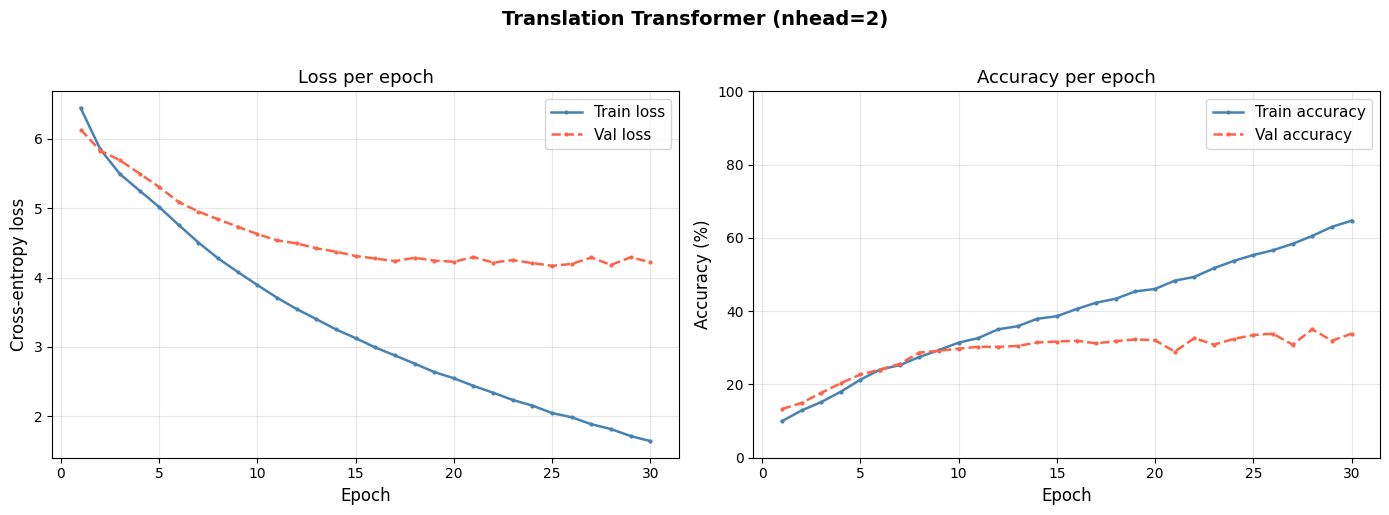

In [17]:
model = TranslationTransformer(
    eta=1e-3, n_iter=30, batch_size=BATCH_SIZE, random_state=42,
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    hidden_size=64, num_layers=2, nhead=2, dropout=0.1,
    pad_idx=Vocabulary.PAD_IDX, dim_feedforward=256
)
model.fit(train_loader, val_loader)

seq_acc, avg_bleu, per_sentence_bleu = evaluate_translations(
    model, src_val_enc, tgt_val_enc, src_vocab, tgt_vocab
)
print(f"Traditional Sequence Accuracy: {seq_acc:.2f}%")
print(f"Validation BLEU-4: {avg_bleu:.4f}")

plot_curves(model, title=f"Translation Transformer (nhead=2)")




=== num_layers=1, nhead=2 ===
Using cuda
Epoch   1/30 | Loss: 6.6052 | Acc: 7.36% | Val Loss: 6.2096 | Val Acc: 13.28% | Time: 0.1s
Epoch   2/30 | Loss: 5.9142 | Acc: 12.72% | Val Loss: 5.8876 | Val Acc: 13.28% | Time: 0.1s
Epoch   3/30 | Loss: 5.5549 | Acc: 13.66% | Val Loss: 5.7188 | Val Acc: 15.79% | Time: 0.1s
Epoch   4/30 | Loss: 5.3216 | Acc: 15.01% | Val Loss: 5.5818 | Val Acc: 19.62% | Time: 0.1s
Epoch   5/30 | Loss: 5.1217 | Acc: 19.51% | Val Loss: 5.4468 | Val Acc: 20.69% | Time: 0.1s
Epoch   6/30 | Loss: 4.9054 | Acc: 21.57% | Val Loss: 5.2785 | Val Acc: 22.49% | Time: 0.2s
Epoch   7/30 | Loss: 4.6854 | Acc: 22.72% | Val Loss: 5.1281 | Val Acc: 23.09% | Time: 0.1s
Epoch   8/30 | Loss: 4.4739 | Acc: 23.60% | Val Loss: 5.0180 | Val Acc: 24.52% | Time: 0.1s
Epoch   9/30 | Loss: 4.2860 | Acc: 25.41% | Val Loss: 4.9380 | Val Acc: 26.20% | Time: 0.1s
Epoch  10/30 | Loss: 4.1042 | Acc: 27.01% | Val Loss: 4.8570 | Val Acc: 27.63% | Time: 0.1s
Epoch  11/30 | Loss: 3.9469 | Acc: 28.1

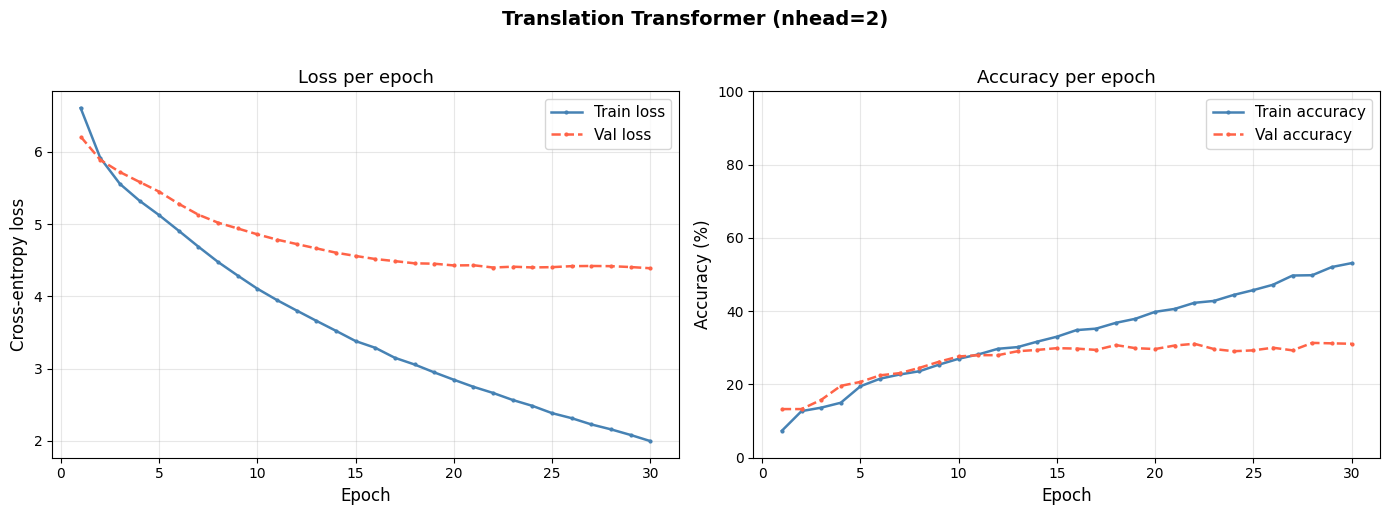


=== num_layers=1, nhead=4 ===
Using cuda
Epoch   1/30 | Loss: 6.6116 | Acc: 7.33% | Val Loss: 6.2161 | Val Acc: 13.28% | Time: 0.1s
Epoch   2/30 | Loss: 5.9102 | Acc: 12.72% | Val Loss: 5.8939 | Val Acc: 13.28% | Time: 0.1s
Epoch   3/30 | Loss: 5.5512 | Acc: 13.38% | Val Loss: 5.7220 | Val Acc: 15.79% | Time: 0.1s
Epoch   4/30 | Loss: 5.3093 | Acc: 15.53% | Val Loss: 5.5803 | Val Acc: 19.86% | Time: 0.1s
Epoch   5/30 | Loss: 5.1029 | Acc: 18.79% | Val Loss: 5.4420 | Val Acc: 21.29% | Time: 0.1s
Epoch   6/30 | Loss: 4.8801 | Acc: 21.31% | Val Loss: 5.2644 | Val Acc: 22.13% | Time: 0.1s
Epoch   7/30 | Loss: 4.6602 | Acc: 22.66% | Val Loss: 5.1168 | Val Acc: 23.33% | Time: 0.1s
Epoch   8/30 | Loss: 4.4457 | Acc: 24.81% | Val Loss: 5.0006 | Val Acc: 25.24% | Time: 0.1s
Epoch   9/30 | Loss: 4.2657 | Acc: 25.81% | Val Loss: 4.9035 | Val Acc: 27.99% | Time: 0.1s
Epoch  10/30 | Loss: 4.0840 | Acc: 27.44% | Val Loss: 4.8328 | Val Acc: 28.23% | Time: 0.1s
Epoch  11/30 | Loss: 3.9286 | Acc: 29.1

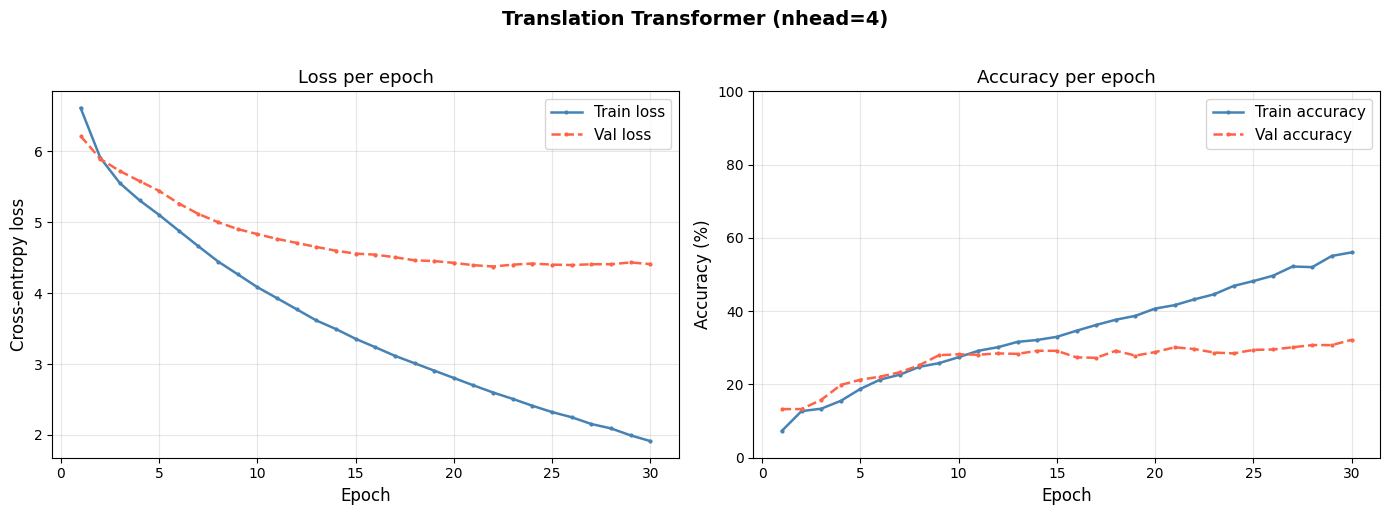


=== num_layers=2, nhead=2 ===
Using cuda
Epoch   1/30 | Loss: 6.4442 | Acc: 9.97% | Val Loss: 6.1338 | Val Acc: 13.28% | Time: 0.2s
Epoch   2/30 | Loss: 5.8489 | Acc: 12.89% | Val Loss: 5.8291 | Val Acc: 14.95% | Time: 0.2s
Epoch   3/30 | Loss: 5.4925 | Acc: 15.18% | Val Loss: 5.6912 | Val Acc: 17.70% | Time: 0.2s
Epoch   4/30 | Loss: 5.2533 | Acc: 18.02% | Val Loss: 5.4987 | Val Acc: 20.33% | Time: 0.2s
Epoch   5/30 | Loss: 5.0160 | Acc: 21.31% | Val Loss: 5.3038 | Val Acc: 22.73% | Time: 0.2s
Epoch   6/30 | Loss: 4.7556 | Acc: 24.06% | Val Loss: 5.0867 | Val Acc: 24.04% | Time: 0.2s
Epoch   7/30 | Loss: 4.5033 | Acc: 25.26% | Val Loss: 4.9508 | Val Acc: 25.60% | Time: 0.2s
Epoch   8/30 | Loss: 4.2758 | Acc: 27.50% | Val Loss: 4.8384 | Val Acc: 28.71% | Time: 0.2s
Epoch   9/30 | Loss: 4.0800 | Acc: 29.39% | Val Loss: 4.7323 | Val Acc: 29.19% | Time: 0.2s
Epoch  10/30 | Loss: 3.8910 | Acc: 31.42% | Val Loss: 4.6261 | Val Acc: 29.78% | Time: 0.2s
Epoch  11/30 | Loss: 3.7082 | Acc: 32.6

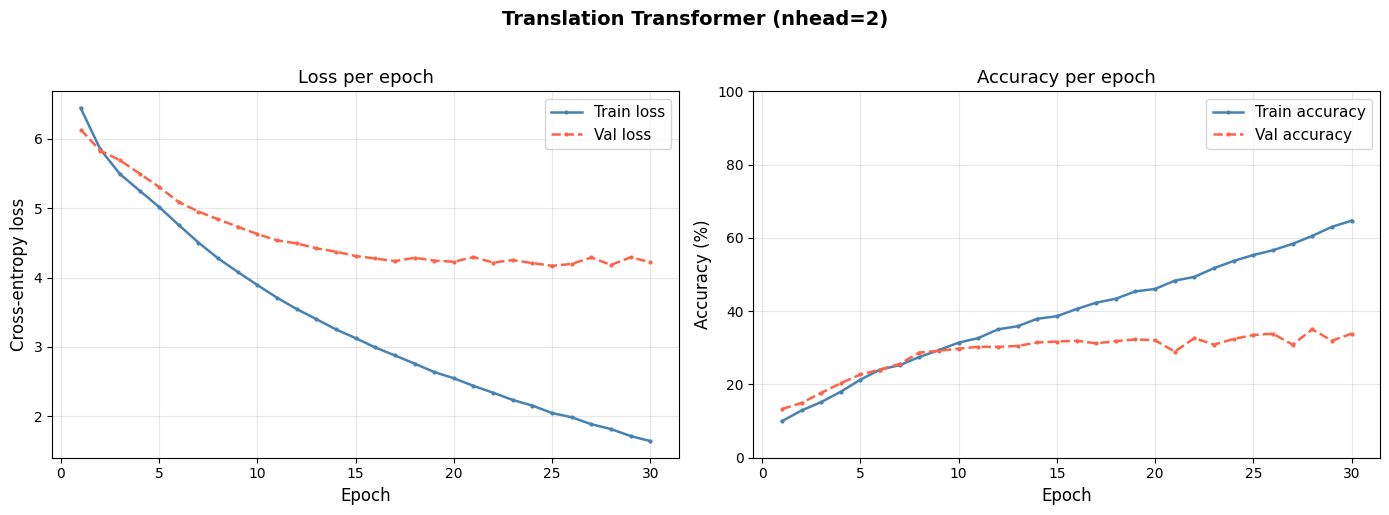


=== num_layers=2, nhead=4 ===
Using cuda
Epoch   1/30 | Loss: 6.4334 | Acc: 10.03% | Val Loss: 6.1222 | Val Acc: 13.28% | Time: 0.2s
Epoch   2/30 | Loss: 5.8402 | Acc: 13.00% | Val Loss: 5.8139 | Val Acc: 14.95% | Time: 0.2s
Epoch   3/30 | Loss: 5.4787 | Acc: 15.44% | Val Loss: 5.6679 | Val Acc: 17.22% | Time: 0.2s
Epoch   4/30 | Loss: 5.2289 | Acc: 17.76% | Val Loss: 5.4766 | Val Acc: 20.57% | Time: 0.2s
Epoch   5/30 | Loss: 4.9923 | Acc: 21.20% | Val Loss: 5.2953 | Val Acc: 22.85% | Time: 0.2s
Epoch   6/30 | Loss: 4.7274 | Acc: 23.92% | Val Loss: 5.0959 | Val Acc: 23.44% | Time: 0.2s
Epoch   7/30 | Loss: 4.4759 | Acc: 24.92% | Val Loss: 4.9247 | Val Acc: 26.79% | Time: 0.2s
Epoch   8/30 | Loss: 4.2519 | Acc: 27.76% | Val Loss: 4.8287 | Val Acc: 27.99% | Time: 0.2s
Epoch   9/30 | Loss: 4.0579 | Acc: 30.13% | Val Loss: 4.7349 | Val Acc: 29.31% | Time: 0.2s
Epoch  10/30 | Loss: 3.8660 | Acc: 31.60% | Val Loss: 4.6377 | Val Acc: 30.38% | Time: 0.2s
Epoch  11/30 | Loss: 3.7092 | Acc: 33.

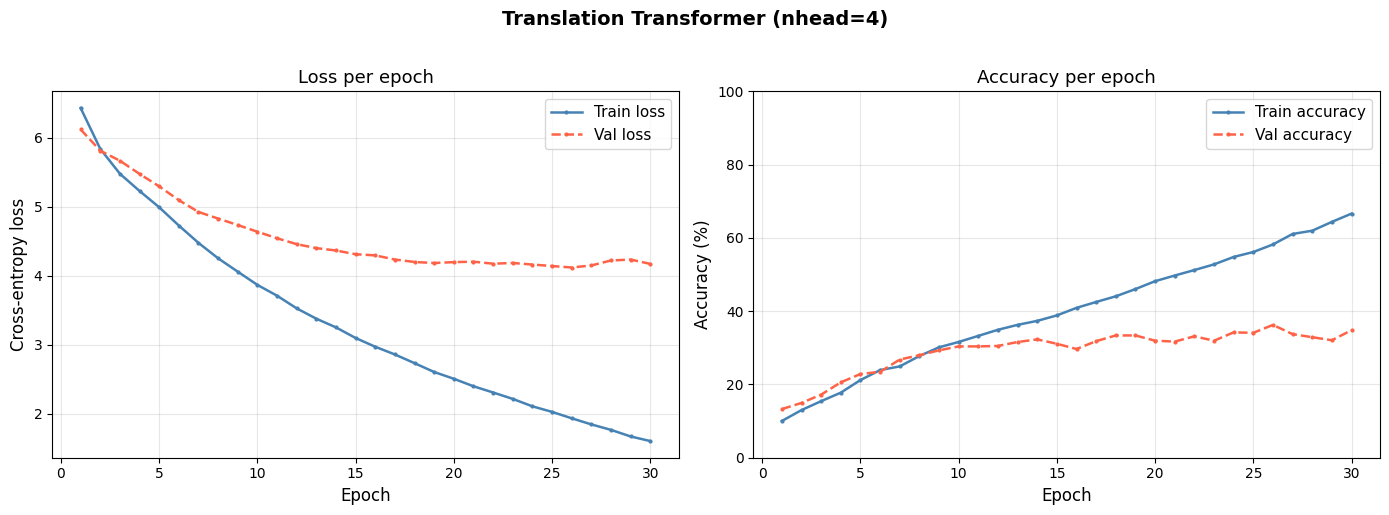


=== num_layers=4, nhead=2 ===
Using cuda
Epoch   1/30 | Loss: 6.3857 | Acc: 11.06% | Val Loss: 6.0763 | Val Acc: 13.28% | Time: 0.4s
Epoch   2/30 | Loss: 5.8094 | Acc: 13.86% | Val Loss: 5.8195 | Val Acc: 14.83% | Time: 0.4s
Epoch   3/30 | Loss: 5.4789 | Acc: 15.75% | Val Loss: 5.6721 | Val Acc: 16.99% | Time: 0.4s
Epoch   4/30 | Loss: 5.2437 | Acc: 17.87% | Val Loss: 5.4570 | Val Acc: 19.38% | Time: 0.4s
Epoch   5/30 | Loss: 5.0109 | Acc: 20.60% | Val Loss: 5.3167 | Val Acc: 21.65% | Time: 0.4s
Epoch   6/30 | Loss: 4.7825 | Acc: 23.69% | Val Loss: 5.1367 | Val Acc: 23.33% | Time: 0.4s
Epoch   7/30 | Loss: 4.5347 | Acc: 25.78% | Val Loss: 4.9773 | Val Acc: 25.24% | Time: 0.4s
Epoch   8/30 | Loss: 4.3033 | Acc: 28.22% | Val Loss: 4.8418 | Val Acc: 26.67% | Time: 0.4s
Epoch   9/30 | Loss: 4.0851 | Acc: 30.08% | Val Loss: 4.6748 | Val Acc: 30.02% | Time: 0.4s
Epoch  10/30 | Loss: 3.8921 | Acc: 32.74% | Val Loss: 4.5790 | Val Acc: 31.34% | Time: 0.4s
Epoch  11/30 | Loss: 3.7079 | Acc: 34.

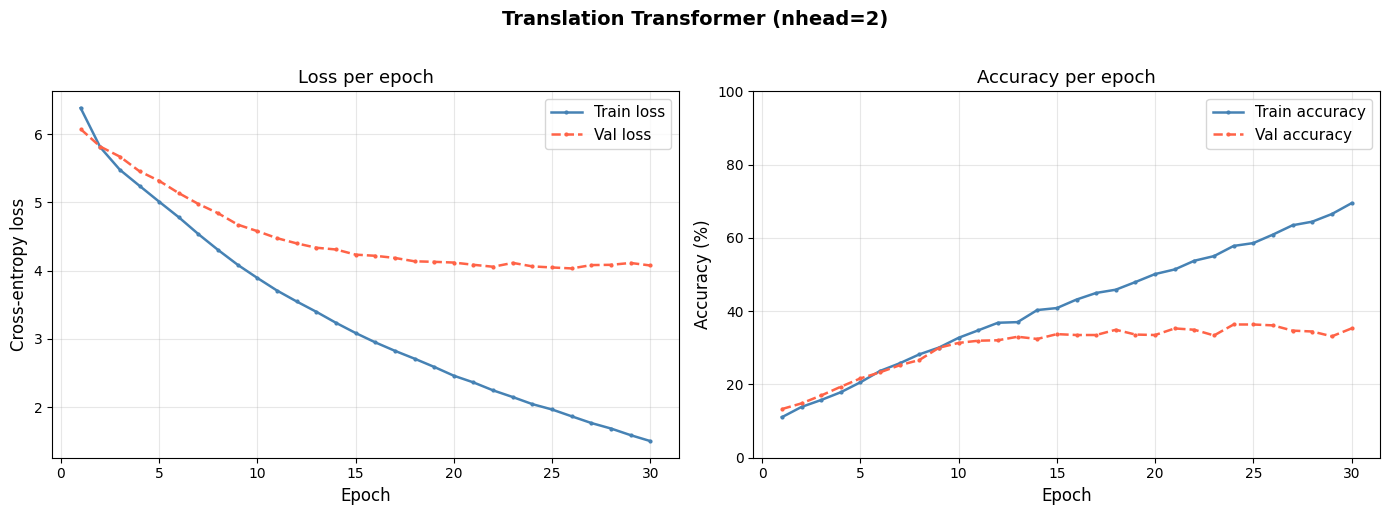


=== num_layers=4, nhead=4 ===
Using cuda
Epoch   1/30 | Loss: 6.3839 | Acc: 11.09% | Val Loss: 6.0687 | Val Acc: 13.28% | Time: 0.4s
Epoch   2/30 | Loss: 5.8133 | Acc: 14.04% | Val Loss: 5.8311 | Val Acc: 14.83% | Time: 0.4s
Epoch   3/30 | Loss: 5.4649 | Acc: 16.59% | Val Loss: 5.6548 | Val Acc: 17.34% | Time: 0.4s
Epoch   4/30 | Loss: 5.2202 | Acc: 17.70% | Val Loss: 5.4660 | Val Acc: 19.38% | Time: 0.4s
Epoch   5/30 | Loss: 4.9816 | Acc: 21.20% | Val Loss: 5.2895 | Val Acc: 21.77% | Time: 0.4s
Epoch   6/30 | Loss: 4.7448 | Acc: 23.80% | Val Loss: 5.1138 | Val Acc: 23.44% | Time: 0.7s
Epoch   7/30 | Loss: 4.5158 | Acc: 25.81% | Val Loss: 4.9479 | Val Acc: 26.56% | Time: 0.7s
Epoch   8/30 | Loss: 4.2676 | Acc: 28.67% | Val Loss: 4.8354 | Val Acc: 27.51% | Time: 0.5s
Epoch   9/30 | Loss: 4.0697 | Acc: 30.79% | Val Loss: 4.6973 | Val Acc: 30.38% | Time: 0.5s
Epoch  10/30 | Loss: 3.8666 | Acc: 32.54% | Val Loss: 4.5785 | Val Acc: 31.34% | Time: 0.5s
Epoch  11/30 | Loss: 3.6783 | Acc: 34.

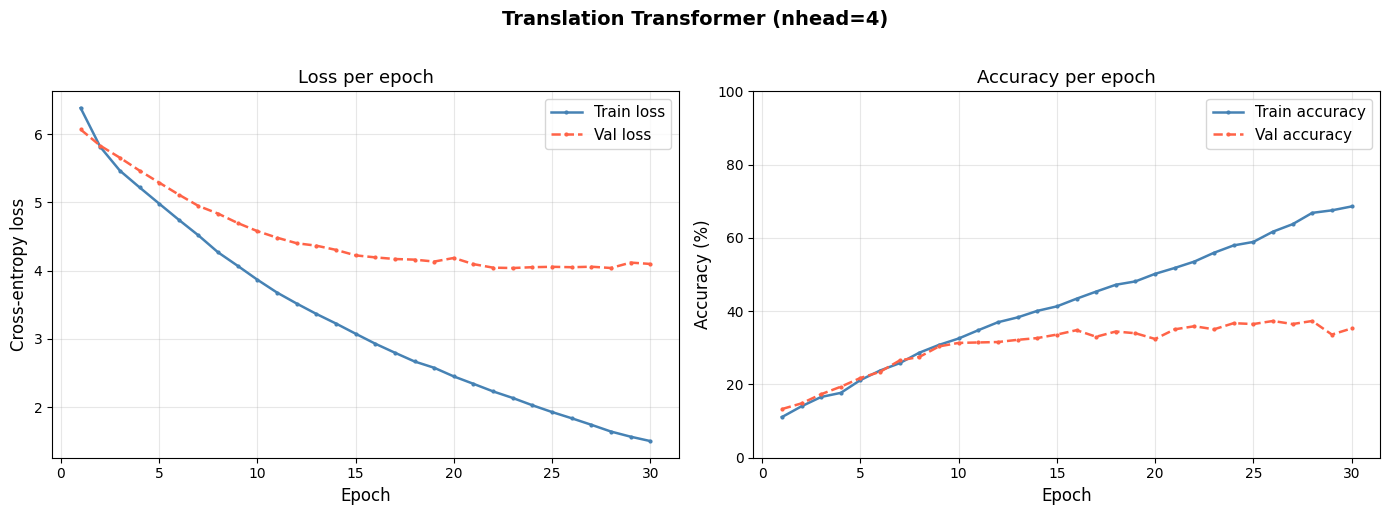

,num_layers,nhead,params,final_train_loss,final_val_loss,seq_accuracy,val_bleu4,training_time_s
0,1,2,302049,1.997006,4.388154,0.000000,0.001742,6.286489
1,1,4,302049,1.913908,4.409724,0.900901,0.015420,4.072430
2,2,2,418785,1.641810,4.220466,0.000000,0.035987,7.955654
3,2,4,418785,1.600038,4.171132,0.000000,0.037956,7.458480
4,4,2,652257,1.500796,4.076005,0.000000,0.032418,13.728588
5,4,4,652257,1.502169,4.098221,0.000000,0.040040,14.447365


In [19]:
sweep_configs = [(1, 2), (1, 4), (2, 2), (2, 4), (4, 2), (4, 4)]
translation_sweep_results = []

# fixed qualitative seed sentences, same across every config for a fair side-by-side
qual_indices = [0, 5, 12, 20, 35]

for num_layers, nhead in sweep_configs:
    print(f"\n=== num_layers={num_layers}, nhead={nhead} ===")
    model = TranslationTransformer(
        eta=1e-3, n_iter=30, batch_size=BATCH_SIZE, random_state=42,
        src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
        hidden_size=64, num_layers=num_layers, nhead=nhead, dropout=0.1,
        pad_idx=Vocabulary.PAD_IDX, dim_feedforward=256
    )
    model.fit(train_loader, val_loader)

    seq_acc, avg_bleu, per_sentence_bleu = evaluate_translations(
        model, src_val_enc, tgt_val_enc, src_vocab, tgt_vocab
    )

    qualitative = []
    for i in qual_indices:
        pred_ids = model.translate(src_val_enc[i], tgt_vocab)
        pred_tokens = tgt_vocab.decode(pred_ids)
        ref_tokens = tgt_vocab.decode(tgt_val_enc[i])
        src_tokens = src_vocab.decode(src_val_enc[i])
        qualitative.append({
            'english': ' '.join(src_tokens),
            'reference_french': ' '.join(ref_tokens),
            'predicted_french': ' '.join(pred_tokens),
            'exact_match': pred_tokens == ref_tokens,
            'bleu': bleu_score(pred_tokens, ref_tokens),
        })

    translation_sweep_results.append({
        'num_layers': num_layers,
        'nhead': nhead,
        'params': model.count_parameters(),
        'final_train_loss': model.train_losses_[-1],
        'final_val_loss': model.val_losses_[-1],
        'seq_accuracy': seq_acc,
        'val_bleu4': avg_bleu,
        'training_time_s': model.training_time_,
        'model': model,
        'qualitative': qualitative,
    })
    plot_curves(model, title=f"Translation Transformer (nhead={nhead})")

translation_sweep_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('model', 'qualitative')}
     for r in translation_sweep_results]
)
translation_sweep_df


In [21]:
for r in translation_sweep_results:
    print(f"\n{'='*70}")
    print(f"num_layers={r['num_layers']}, nhead={r['nhead']}  "
          f"(val_bleu4={r['val_bleu4']:.4f}, seq_acc={r['seq_accuracy']:.2f}%)")
    print('='*70)
    for q in r['qualitative']:
        match_flag = "EXACT MATCH" if q['exact_match'] else ""
        print(f"\nEN:   {q['english']}")
        print(f"REF:  {q['reference_french']}")
        print(f"PRED: {q['predicted_french']}   (BLEU={q['bleu']:.3f}) {match_flag}")


num_layers=1, nhead=2  (val_bleu4=0.0017, seq_acc=0.00%)

EN:   she won a tennis match
REF:  elle a gagné un match de tennis
PRED: elle a acheté un tournoi   (BLEU=0.000) 

EN:   they live in a beautiful apartment <unk> the river
REF:  ils vivent dans un <unk> appartement <unk> à la rivière
PRED: ils ont construit une grande maison   (BLEU=0.000) 

EN:   he drives a black sedan
REF:  il conduit une berline noire
PRED: il conduit une voiture bleue   (BLEU=0.000) 

EN:   the beautiful spring flowers are <unk> blooming
REF:  les <unk> fleurs du printemps <unk> <unk>
PRED: les enfants   (BLEU=0.000) 

EN:   the <unk> <unk> a <unk> of time
REF:  le <unk> <unk> <unk> de temps
PRED: les oiseaux un feu de jazz   (BLEU=0.000) 

num_layers=1, nhead=4  (val_bleu4=0.0154, seq_acc=0.90%)

EN:   she won a tennis match
REF:  elle a gagné un match de tennis
PRED: elle a acheté un tournoi   (BLEU=0.000) 

EN:   they live in a beautiful apartment <unk> the river
REF:  ils vivent dans un <unk> apparteme

In [20]:
for s in tgt_train:
    if 'conduit' in s or 'voiture' in s:
        print(' '.join(s))

il conduit une voiture bleue
il répare la voiture
il conduit une berline de luxe noire pour aller au travail
il conduit une moto rouge
nous planifions un grand voyage en voiture à travers le canada
il conduit un camion vert
elle conduit une voiture rapide


In [22]:
# ── Reversed tensors: French → source, English → target
# For Problem 3 we simply swap them

# Re-encode with swapped roles
src_train_enc_r = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_train]
src_val_enc_r   = [encode_and_pad(t, tgt_vocab, NUM_STEPS) for t in tgt_val]
tgt_train_enc_r = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_train]
tgt_val_enc_r   = [encode_and_pad(s, src_vocab, NUM_STEPS) for s in src_val]

src_train_r = torch.tensor(src_train_enc_r, dtype=torch.long)
src_val_r   = torch.tensor(src_val_enc_r,   dtype=torch.long)
tgt_train_r = torch.tensor(tgt_train_enc_r, dtype=torch.long)
tgt_val_r   = torch.tensor(tgt_val_enc_r,   dtype=torch.long)

print(f"src_train_r (French input)   : {src_train_r.shape}")
print(f"tgt_train_r (English output) : {tgt_train_r.shape}")

train_dataset_r = TensorDataset(src_train_r, tgt_train_r)
val_dataset_r   = TensorDataset(src_val_r,   tgt_val_r)
train_loader_r  = DataLoader(train_dataset_r, batch_size=32, shuffle=True)
val_loader_r    = DataLoader(val_dataset_r,   batch_size=32, shuffle=False)

src_train_r (French input)   : torch.Size([444, 15])
tgt_train_r (English output) : torch.Size([444, 15])


In [23]:
dec_input_train_r = make_decoder_input(tgt_train_r, src_vocab.BOS_IDX)
dec_input_val_r   = make_decoder_input(tgt_val_r, src_vocab.BOS_IDX)

train_dataset_r = TensorDataset(src_train_r, dec_input_train_r, tgt_train_r)
val_dataset_r   = TensorDataset(src_val_r,   dec_input_val_r,   tgt_val_r)
train_loader_r  = DataLoader(train_dataset_r, batch_size=32, shuffle=True)
val_loader_r    = DataLoader(val_dataset_r,   batch_size=32, shuffle=False)


=== [FR->EN] num_layers=1, nhead=2 ===
Using cuda
Epoch   1/30 | Loss: 6.4299 | Acc: 7.20% | Val Loss: 5.9806 | Val Acc: 13.93% | Time: 0.1s


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch   2/30 | Loss: 5.7291 | Acc: 13.76% | Val Loss: 5.6183 | Val Acc: 16.81% | Time: 0.1s
Epoch   3/30 | Loss: 5.3421 | Acc: 17.09% | Val Loss: 5.4169 | Val Acc: 18.70% | Time: 0.1s
Epoch   4/30 | Loss: 5.0634 | Acc: 18.98% | Val Loss: 5.2653 | Val Acc: 19.45% | Time: 0.1s
Epoch   5/30 | Loss: 4.8354 | Acc: 20.72% | Val Loss: 5.1140 | Val Acc: 21.83% | Time: 0.3s
Epoch   6/30 | Loss: 4.5973 | Acc: 23.59% | Val Loss: 4.9443 | Val Acc: 26.98% | Time: 0.4s
Epoch   7/30 | Loss: 4.3781 | Acc: 27.46% | Val Loss: 4.8362 | Val Acc: 29.61% | Time: 0.2s
Epoch   8/30 | Loss: 4.1922 | Acc: 29.75% | Val Loss: 4.7719 | Val Acc: 29.99% | Time: 0.1s
Epoch   9/30 | Loss: 4.0227 | Acc: 30.76% | Val Loss: 4.7110 | Val Acc: 30.24% | Time: 0.1s
Epoch  10/30 | Loss: 3.8689 | Acc: 32.99% | Val Loss: 4.6418 | Val Acc: 30.99% | Time: 0.1s
Epoch  11/30 | Loss: 3.7112 | Acc: 34.03% | Val Loss: 4.6087 | Val Acc: 30.87% | Time: 0.1s
Epoch  12/30 | Loss: 3.5689 | Acc: 36.34% | Val Loss: 4.5528 | Val Acc: 30.61% |

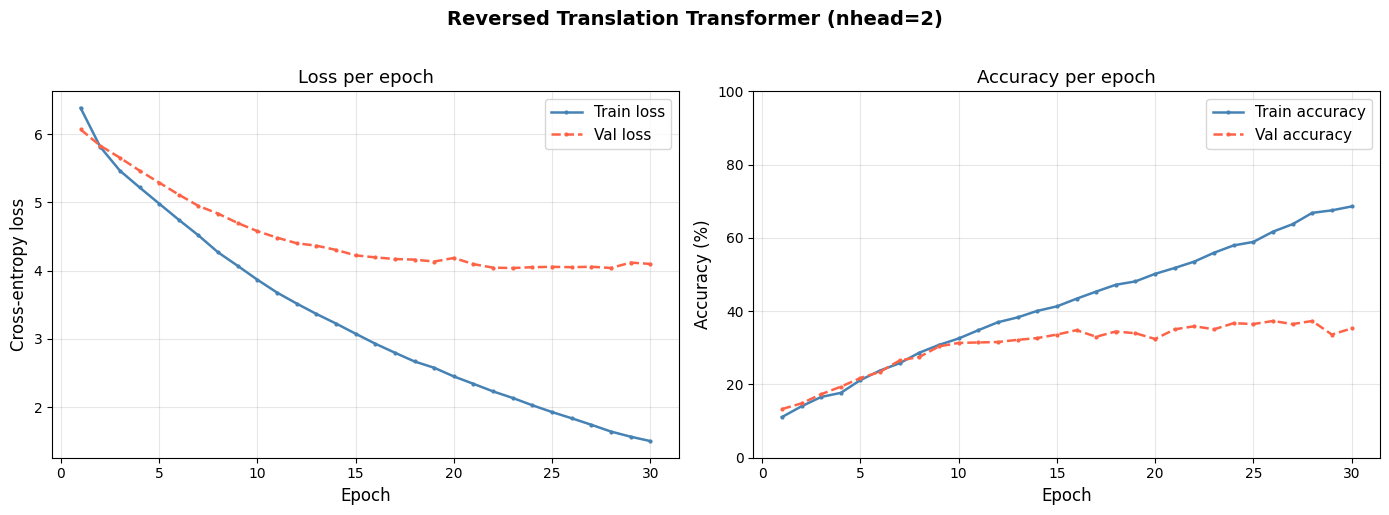


=== [FR->EN] num_layers=1, nhead=4 ===
Using cuda
Epoch   1/30 | Loss: 6.4269 | Acc: 7.45% | Val Loss: 5.9923 | Val Acc: 13.93% | Time: 0.1s
Epoch   2/30 | Loss: 5.7306 | Acc: 13.67% | Val Loss: 5.6294 | Val Acc: 14.30% | Time: 0.1s
Epoch   3/30 | Loss: 5.3440 | Acc: 16.91% | Val Loss: 5.4262 | Val Acc: 18.95% | Time: 0.1s
Epoch   4/30 | Loss: 5.0591 | Acc: 18.40% | Val Loss: 5.2793 | Val Acc: 20.08% | Time: 0.1s
Epoch   5/30 | Loss: 4.8132 | Acc: 20.51% | Val Loss: 5.1271 | Val Acc: 22.58% | Time: 0.1s
Epoch   6/30 | Loss: 4.5992 | Acc: 23.74% | Val Loss: 4.9713 | Val Acc: 26.98% | Time: 0.1s
Epoch   7/30 | Loss: 4.3718 | Acc: 27.56% | Val Loss: 4.8497 | Val Acc: 30.11% | Time: 0.1s
Epoch   8/30 | Loss: 4.1512 | Acc: 30.24% | Val Loss: 4.7623 | Val Acc: 30.61% | Time: 0.1s
Epoch   9/30 | Loss: 3.9628 | Acc: 32.77% | Val Loss: 4.6814 | Val Acc: 30.87% | Time: 0.1s
Epoch  10/30 | Loss: 3.8094 | Acc: 33.84% | Val Loss: 4.6245 | Val Acc: 30.61% | Time: 0.1s
Epoch  11/30 | Loss: 3.6576 | 

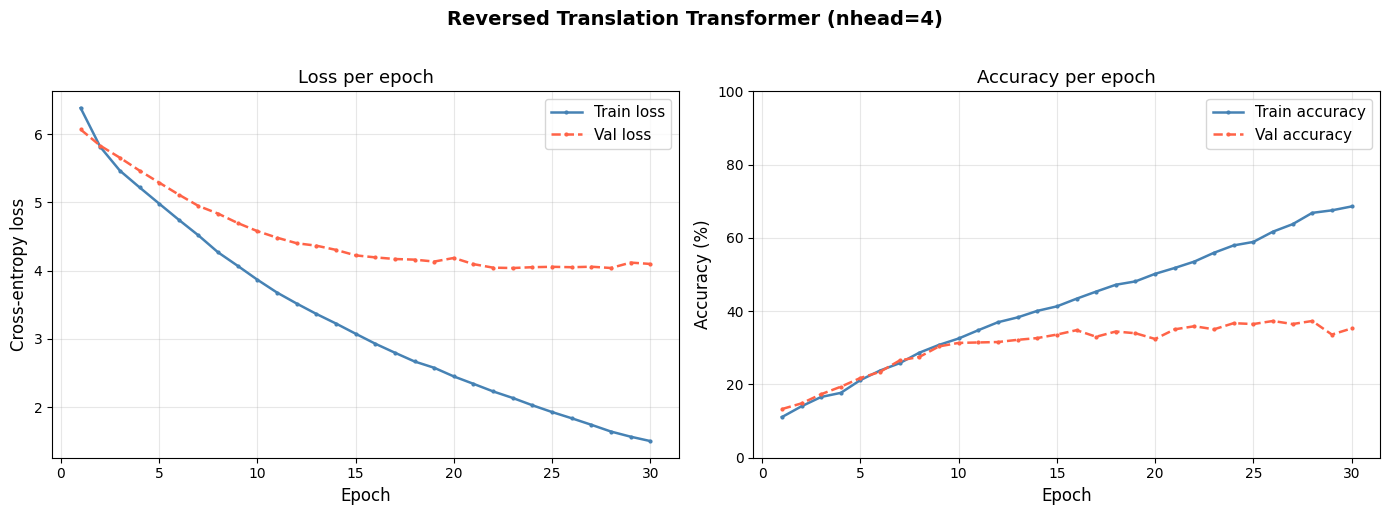


=== [FR->EN] num_layers=2, nhead=2 ===
Using cuda
Epoch   1/30 | Loss: 6.2928 | Acc: 10.41% | Val Loss: 5.9476 | Val Acc: 13.93% | Time: 0.2s
Epoch   2/30 | Loss: 5.6768 | Acc: 14.28% | Val Loss: 5.5602 | Val Acc: 18.44% | Time: 0.2s
Epoch   3/30 | Loss: 5.2733 | Acc: 19.10% | Val Loss: 5.3584 | Val Acc: 20.83% | Time: 0.2s
Epoch   4/30 | Loss: 4.9555 | Acc: 22.52% | Val Loss: 5.1447 | Val Acc: 23.34% | Time: 0.2s
Epoch   5/30 | Loss: 4.6468 | Acc: 26.73% | Val Loss: 4.9180 | Val Acc: 28.73% | Time: 0.2s
Epoch   6/30 | Loss: 4.3749 | Acc: 30.03% | Val Loss: 4.8257 | Val Acc: 28.36% | Time: 0.2s
Epoch   7/30 | Loss: 4.1565 | Acc: 32.41% | Val Loss: 4.6895 | Val Acc: 30.87% | Time: 0.2s
Epoch   8/30 | Loss: 3.9413 | Acc: 35.12% | Val Loss: 4.6202 | Val Acc: 31.99% | Time: 0.2s
Epoch   9/30 | Loss: 3.7793 | Acc: 36.65% | Val Loss: 4.5382 | Val Acc: 32.87% | Time: 0.2s
Epoch  10/30 | Loss: 3.5960 | Acc: 37.96% | Val Loss: 4.4590 | Val Acc: 34.38% | Time: 0.2s
Epoch  11/30 | Loss: 3.4393 |

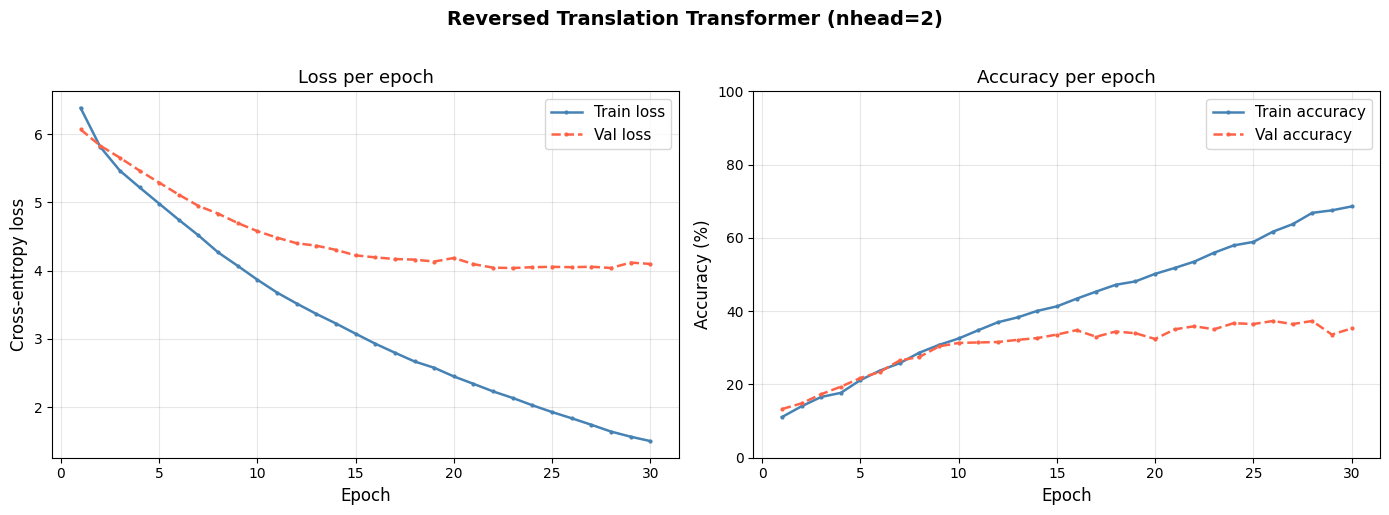


=== [FR->EN] num_layers=2, nhead=4 ===
Using cuda
Epoch   1/30 | Loss: 6.2957 | Acc: 10.44% | Val Loss: 5.9481 | Val Acc: 13.93% | Time: 0.2s
Epoch   2/30 | Loss: 5.6798 | Acc: 14.10% | Val Loss: 5.5691 | Val Acc: 18.32% | Time: 0.2s
Epoch   3/30 | Loss: 5.2741 | Acc: 18.80% | Val Loss: 5.3768 | Val Acc: 20.83% | Time: 0.2s
Epoch   4/30 | Loss: 4.9651 | Acc: 21.45% | Val Loss: 5.1741 | Val Acc: 22.96% | Time: 0.2s
Epoch   5/30 | Loss: 4.6596 | Acc: 25.54% | Val Loss: 4.9526 | Val Acc: 27.73% | Time: 0.2s
Epoch   6/30 | Loss: 4.3974 | Acc: 28.99% | Val Loss: 4.8094 | Val Acc: 28.98% | Time: 0.2s
Epoch   7/30 | Loss: 4.1389 | Acc: 32.50% | Val Loss: 4.6848 | Val Acc: 31.74% | Time: 0.2s
Epoch   8/30 | Loss: 3.9306 | Acc: 34.70% | Val Loss: 4.6034 | Val Acc: 33.50% | Time: 0.2s
Epoch   9/30 | Loss: 3.7517 | Acc: 36.41% | Val Loss: 4.5372 | Val Acc: 32.12% | Time: 0.2s
Epoch  10/30 | Loss: 3.5583 | Acc: 38.75% | Val Loss: 4.4606 | Val Acc: 33.38% | Time: 0.2s
Epoch  11/30 | Loss: 3.4069 |

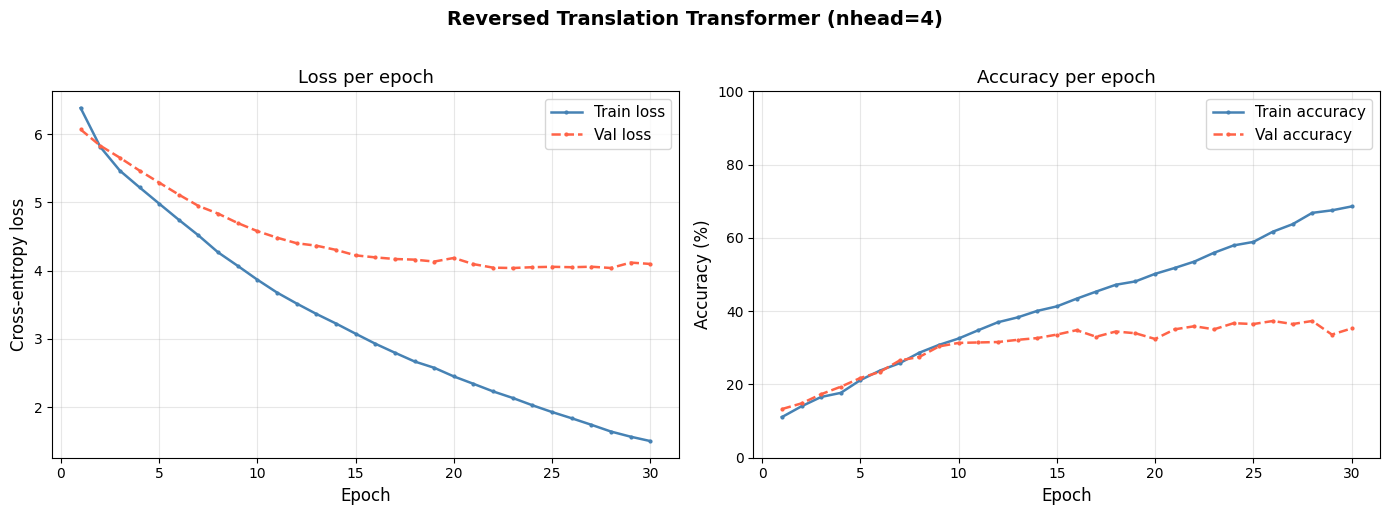


=== [FR->EN] num_layers=4, nhead=2 ===
Using cuda
Epoch   1/30 | Loss: 6.2564 | Acc: 11.57% | Val Loss: 5.9318 | Val Acc: 13.93% | Time: 0.4s
Epoch   2/30 | Loss: 5.6613 | Acc: 15.84% | Val Loss: 5.5275 | Val Acc: 19.70% | Time: 0.4s
Epoch   3/30 | Loss: 5.2664 | Acc: 19.74% | Val Loss: 5.3234 | Val Acc: 23.09% | Time: 0.4s
Epoch   4/30 | Loss: 4.9694 | Acc: 23.07% | Val Loss: 5.1645 | Val Acc: 23.96% | Time: 0.4s
Epoch   5/30 | Loss: 4.6940 | Acc: 26.21% | Val Loss: 4.9711 | Val Acc: 27.35% | Time: 0.4s
Epoch   6/30 | Loss: 4.4208 | Acc: 29.91% | Val Loss: 4.8398 | Val Acc: 29.86% | Time: 0.4s
Epoch   7/30 | Loss: 4.1647 | Acc: 32.96% | Val Loss: 4.6796 | Val Acc: 32.50% | Time: 0.4s
Epoch   8/30 | Loss: 3.9472 | Acc: 35.00% | Val Loss: 4.6136 | Val Acc: 32.75% | Time: 0.4s
Epoch   9/30 | Loss: 3.7348 | Acc: 37.38% | Val Loss: 4.4775 | Val Acc: 34.00% | Time: 0.4s
Epoch  10/30 | Loss: 3.5570 | Acc: 39.82% | Val Loss: 4.3598 | Val Acc: 35.26% | Time: 0.4s
Epoch  11/30 | Loss: 3.3944 |

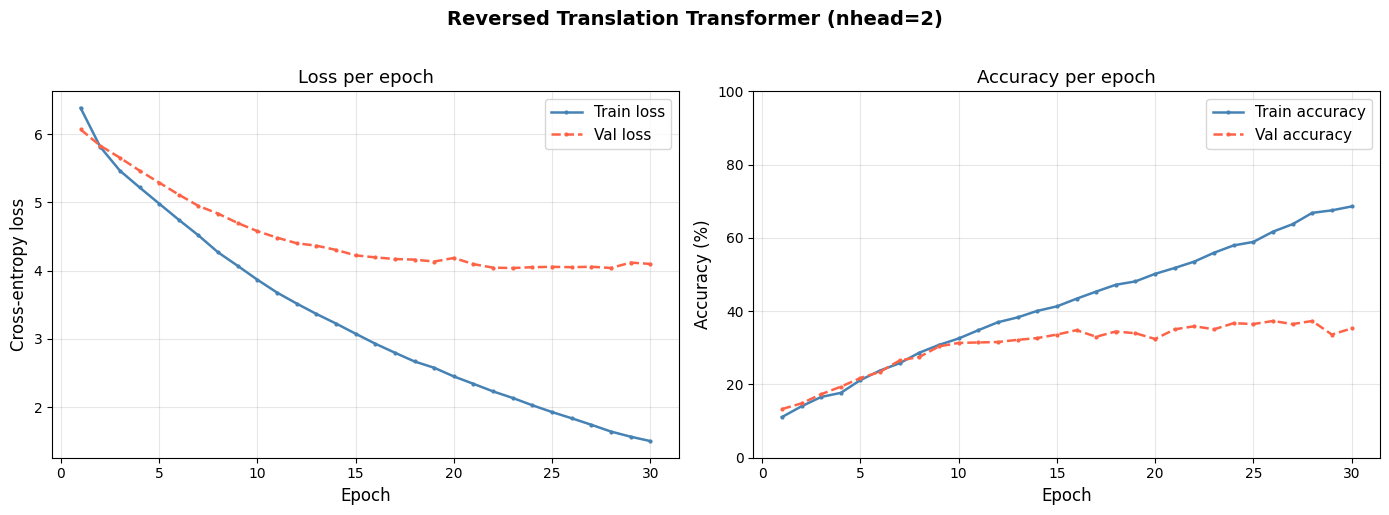


=== [FR->EN] num_layers=4, nhead=4 ===
Using cuda
Epoch   1/30 | Loss: 6.2550 | Acc: 11.53% | Val Loss: 5.9330 | Val Acc: 13.93% | Time: 0.4s
Epoch   2/30 | Loss: 5.6607 | Acc: 15.65% | Val Loss: 5.5517 | Val Acc: 19.32% | Time: 0.4s
Epoch   3/30 | Loss: 5.2627 | Acc: 20.11% | Val Loss: 5.3296 | Val Acc: 22.96% | Time: 0.4s
Epoch   4/30 | Loss: 4.9537 | Acc: 23.62% | Val Loss: 5.1389 | Val Acc: 25.47% | Time: 0.4s
Epoch   5/30 | Loss: 4.6531 | Acc: 27.19% | Val Loss: 4.9932 | Val Acc: 26.22% | Time: 0.4s
Epoch   6/30 | Loss: 4.3856 | Acc: 30.36% | Val Loss: 4.7801 | Val Acc: 30.61% | Time: 0.4s
Epoch   7/30 | Loss: 4.1320 | Acc: 34.06% | Val Loss: 4.7124 | Val Acc: 29.99% | Time: 0.4s
Epoch   8/30 | Loss: 3.9150 | Acc: 35.31% | Val Loss: 4.5698 | Val Acc: 32.75% | Time: 0.4s
Epoch   9/30 | Loss: 3.7135 | Acc: 37.75% | Val Loss: 4.4456 | Val Acc: 33.38% | Time: 0.5s
Epoch  10/30 | Loss: 3.5158 | Acc: 40.31% | Val Loss: 4.3746 | Val Acc: 34.88% | Time: 0.6s
Epoch  11/30 | Loss: 3.3498 |

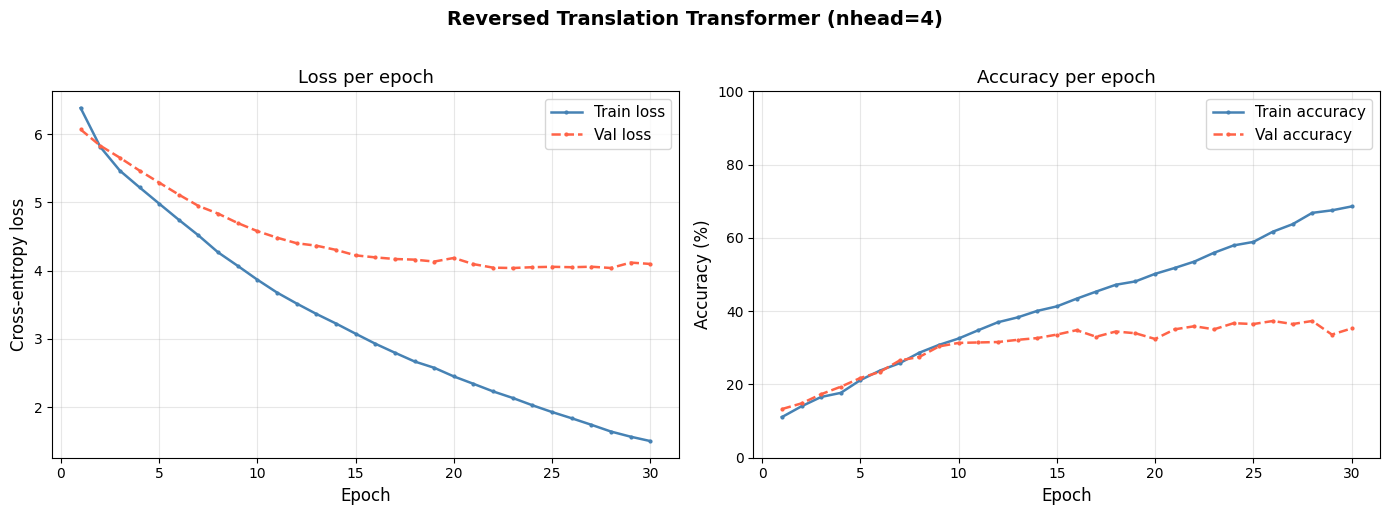

,num_layers,nhead,params,final_train_loss,final_val_loss,seq_accuracy,val_bleu4,training_time_s
0,1,2,295614,1.821171,4.283817,0.0,0.014904,5.638523
1,1,4,295614,1.728876,4.238044,0.0,0.018013,4.126588
2,2,2,412350,1.461545,4.032886,0.0,0.028180,8.043644
3,2,4,412350,1.422370,4.075892,0.0,0.031686,7.368871
4,4,2,645822,1.328184,3.947355,0.0,0.037156,14.060504
5,4,4,645822,1.270063,3.955392,0.0,0.018233,14.097007


In [26]:
sweep_configs = [(1, 2), (1, 4), (2, 2), (2, 4), (4, 2), (4, 4)]
qual_indices = [0, 5, 12, 20, 35]
reversed_sweep_results = []

for num_layers, nhead in sweep_configs:
    print(f"\n=== [FR->EN] num_layers={num_layers}, nhead={nhead} ===")
    model_r = TranslationTransformer(
        eta=1e-3, n_iter=30, batch_size=32, random_state=42,
        src_vocab_size=len(tgt_vocab),   # French is now the source
        tgt_vocab_size=len(src_vocab),   # English is now the target
        hidden_size=64, num_layers=num_layers, nhead=nhead, dropout=0.1,
        pad_idx=Vocabulary.PAD_IDX, dim_feedforward=256
    )
    model_r.fit(train_loader_r, val_loader_r)

    seq_acc, avg_bleu, per_sentence_bleu = evaluate_translations(
        model_r, src_val_enc_r, tgt_val_enc_r, tgt_vocab, src_vocab
    )

    qualitative = []
    for i in qual_indices:
        pred_ids = model_r.translate(src_val_enc_r[i], src_vocab)
        pred_tokens = src_vocab.decode(pred_ids)
        ref_tokens = src_vocab.decode(tgt_val_enc_r[i])
        fr_tokens = tgt_vocab.decode(src_val_enc_r[i])
        qualitative.append({
            'french': ' '.join(fr_tokens),
            'reference_english': ' '.join(ref_tokens),
            'predicted_english': ' '.join(pred_tokens),
            'exact_match': pred_tokens == ref_tokens,
            'bleu': bleu_score(pred_tokens, ref_tokens),
        })

    reversed_sweep_results.append({
        'num_layers': num_layers, 'nhead': nhead,
        'params': model_r.count_parameters(),
        'final_train_loss': model_r.train_losses_[-1],
        'final_val_loss': model_r.val_losses_[-1],
        'seq_accuracy': seq_acc,
        'val_bleu4': avg_bleu,
        'training_time_s': model_r.training_time_,
        'model': model_r,
        'qualitative': qualitative,
    })

    plot_curves(model, title=f"Reversed Translation Transformer (nhead={nhead})")

reversed_sweep_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('model', 'qualitative')}
     for r in reversed_sweep_results]
)
reversed_sweep_df




In [27]:
for r in reversed_sweep_results:
    print(f"\n{'='*70}")
    print(f"[FR->EN] num_layers={r['num_layers']}, nhead={r['nhead']}  "
          f"(val_bleu4={r['val_bleu4']:.4f}, seq_acc={r['seq_accuracy']:.2f}%)")
    print('='*70)
    for q in r['qualitative']:
        match_flag = "EXACT MATCH" if q['exact_match'] else ""
        print(f"\nFR:   {q['french']}")
        print(f"REF:  {q['reference_english']}")
        print(f"PRED: {q['predicted_english']}   (BLEU={q['bleu']:.3f}) {match_flag}")


[FR->EN] num_layers=1, nhead=2  (val_bleu4=0.0149, seq_acc=0.00%)

FR:   elle a gagné un match de tennis
REF:  she won a tennis match
PRED: she won a beautiful a beautiful a beautiful a beautiful a beautiful a beautiful a   (BLEU=0.000) 

FR:   ils vivent dans un <unk> appartement <unk> à la rivière
REF:  they live in a beautiful apartment <unk> the river
PRED: they built a cozy to the party   (BLEU=0.000) 

FR:   il conduit une berline noire
REF:  he drives a black sedan
PRED: he drives a red motorcycle   (BLEU=0.000) 

FR:   les <unk> fleurs du printemps <unk> <unk>
REF:  the beautiful spring flowers are <unk> blooming
PRED: the ocean the ocean the ocean the ocean   (BLEU=0.000) 

FR:   le <unk> <unk> <unk> de temps
REF:  the <unk> <unk> a <unk> of time
PRED: the ocean   (BLEU=0.000) 

[FR->EN] num_layers=1, nhead=4  (val_bleu4=0.0180, seq_acc=0.00%)

FR:   elle a gagné un match de tennis
REF:  she won a tennis match
PRED: she won a highly   (BLEU=0.000) 

FR:   ils vivent dans un <